# Cài đặt thư viện

In [1]:
!pip install torchinfo

In [2]:
!pip install thop

In [ ]:
import os
import time
import math
import gc
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import seasonal_decompose

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from torchinfo import summary
from thop import profile, clever_format

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Dataset

In [5]:
PROJECT_PATH = '/content/drive/MyDrive/Datasets_AMR_Projects/all_six_datasets/electricity/'
# '/content/drive/MyDrive/Datasets_AMR_Projects/all_six_datasets/electricity/'
# '/content/drive/MyDrive/Datasets_AMR_Projects/all_six_datasets/exchange_rate/'
# '/content/drive/MyDrive/Datasets_AMR_Projects/all_six_datasets/traffic/'
# '/content/drive/MyDrive/Datasets_AMR_Projects/all_six_datasets/weather/'

# Tham số cho dữ liệu
INPUT_LEN = 96      # Độ dài chuỗi quá khứ để nhìn lại (4 ngày)
OUTPUT_LEN = 15     # Độ dài chuỗi tương lai cần dự báo

# Tham số cho mô hình
BATCH_SIZE = 32
COMMON_D_MODEL = 64 # Kích thước vector nội tại của mô hình
COMMON_NHEAD = 4    # Số lượng head trong Multi-Head Attention

# Tham số cho huấn luyện
NUM_EPOCHS = 40
LEARNING_RATE = 0.0005
PATIENCE = 5
COMMON_DROPOUT = 0.2

# Tải và chuẩn bị dữ liệu

In [6]:
# --- 1.1 Tải dữ liệu ---
dts_name = 'electricity.csv'
df = pd.read_csv(PROJECT_PATH + dts_name, index_col='date', parse_dates=True)
print("Tải dữ liệu thành công. Dữ liệu có", df.shape[0], "dòng và", df.shape[1], "cột.")

Tải dữ liệu thành công. Dữ liệu có 26304 dòng và 321 cột.


In [7]:
# --- 1.2 Khám phá dữ liệu (EDA) ---
sns.set_style('whitegrid')
target = 'OT'

In [8]:
# a. Xem thông tin cơ bản và kiểm tra dữ liệu thiếu
print("\n1. Thông tin tổng quan và dữ liệu thiếu:")
df.info()
print("\nSố lượng giá trị thiếu mỗi cột:", df.isnull().sum().sum()) # Tổng số giá trị thiếu


1. Thông tin tổng quan và dữ liệu thiếu:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26304 entries, 2016-07-01 02:00:00 to 2019-07-02 01:00:00
Columns: 321 entries, 0 to OT
dtypes: float64(321)
memory usage: 64.6 MB

Số lượng giá trị thiếu mỗi cột: 0


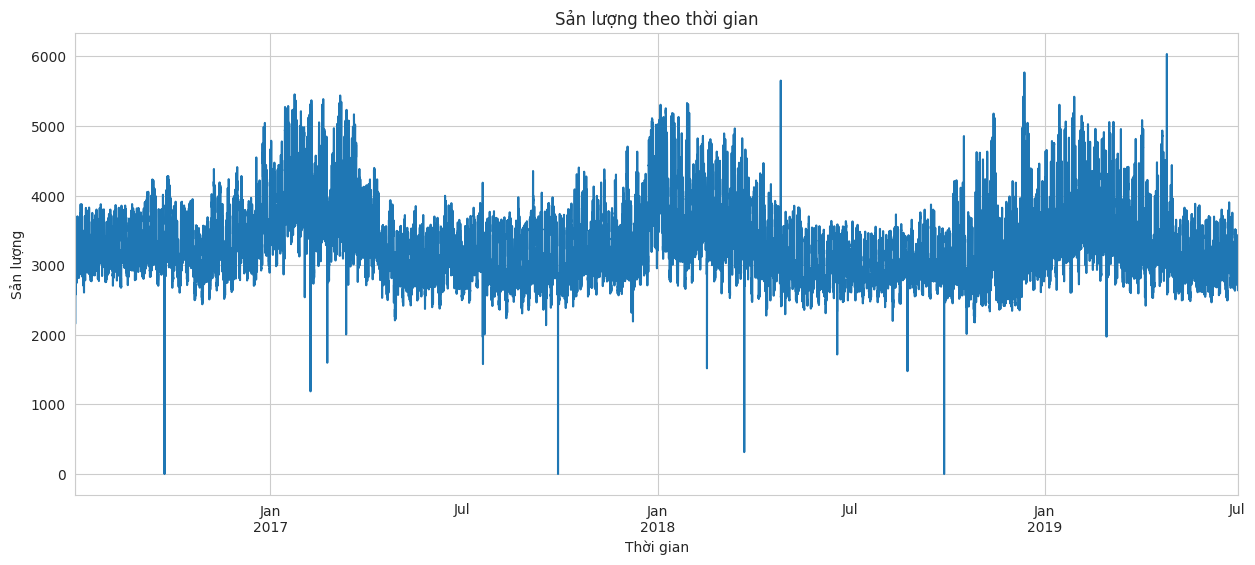

In [9]:
# b. Trực quan hóa chuỗi thời gian mục tiêu
plt.figure(figsize=(15, 6))
df[target].plot(title='Sản lượng theo thời gian')
plt.ylabel('Sản lượng')
plt.xlabel('Thời gian')
plt.show()


2. Phân rã chuỗi thời gian để xem các thành phần:


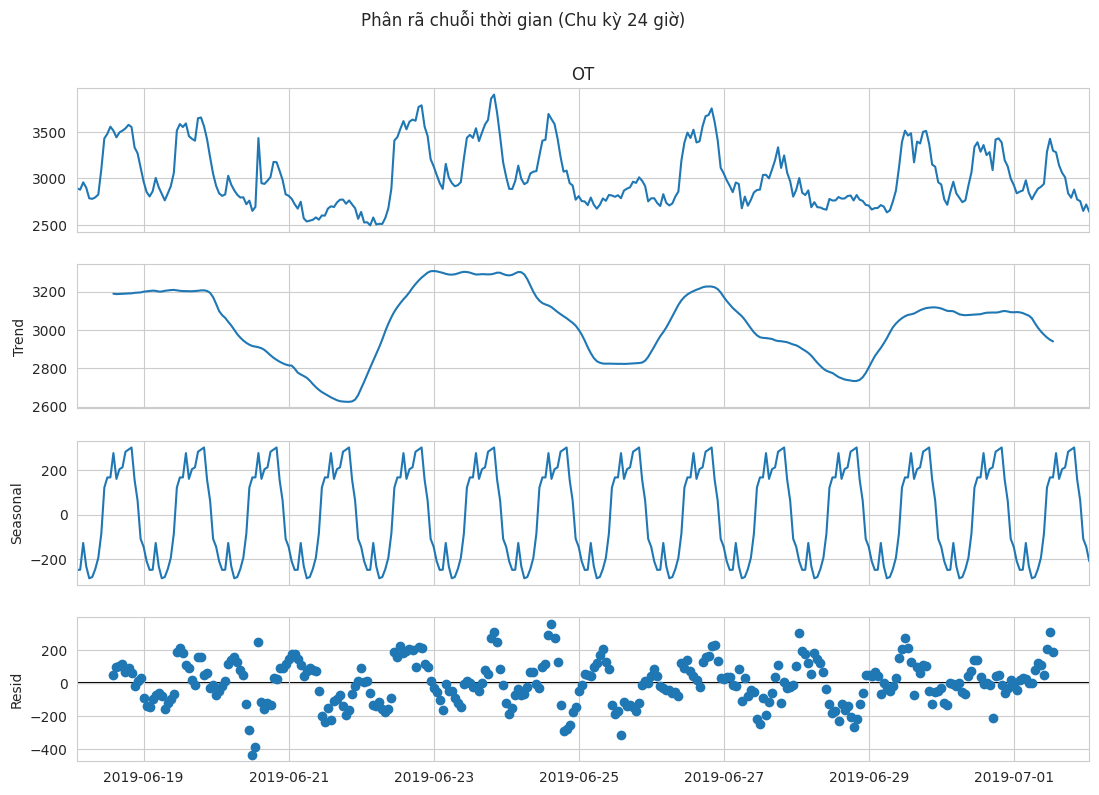

In [10]:
# c. Phân rã chuỗi thời gian để xem xu hướng và mùa vụ
print("\n2. Phân rã chuỗi thời gian để xem các thành phần:")
# Lấy một phần dữ liệu (khoảng 2 tuần) để biểu đồ rõ ràng hơn
subset_for_decomposition = df[target][-24*14:]
result = seasonal_decompose(subset_for_decomposition, model='additive', period=24)
fig = result.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Phân rã chuỗi thời gian (Chu kỳ 24 giờ)', y=1.02)
plt.show()

# Tiền xử lý

In [11]:
# Chọn cột dữ liệu đơn biến và reshape
data = df[target].values.reshape(-1, 1)

# Chia dữ liệu Train/Val/Test
train_size = int(len(data) * 0.7)
val_size = int(len(data) * 0.1)
train_data = data[:train_size]
val_data = data[train_size:train_size + val_size]
test_data = data[train_size + val_size:]

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
train_data_scaled = scaler.fit_transform(train_data)
val_data_scaled = scaler.transform(val_data)
test_data_scaled = scaler.transform(test_data)

# Hàm tạo các chuỗi đầu vào và nhãn
def create_sequences(data, input_len, output_len):
    sequences, labels = [], []
    for i in range(len(data) - input_len - output_len + 1):
        sequences.append(data[i:i + input_len])
        labels.append(data[i + input_len:i + input_len + output_len])
    return np.array(sequences), np.array(labels)

# Tạo các bộ dữ liệu X, y
X_train, y_train = create_sequences(train_data_scaled, INPUT_LEN, OUTPUT_LEN)
X_val, y_val = create_sequences(val_data_scaled, INPUT_LEN, OUTPUT_LEN)
X_test, y_test = create_sequences(test_data_scaled, INPUT_LEN, OUTPUT_LEN)

# Chuyển đổi sang PyTorch Tensors
X_train_tensor, y_train_tensor = torch.FloatTensor(X_train), torch.FloatTensor(y_train)
X_val_tensor, y_val_tensor = torch.FloatTensor(X_val), torch.FloatTensor(y_val)
X_test_tensor, y_test_tensor = torch.FloatTensor(X_test), torch.FloatTensor(y_test)

# Tạo DataLoader để quản lý các batch
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Định nghĩa kiến trúc mô hình

## AMR


In [ ]:
# =========================================================
# 1) RevIN (Reversible Instance Normalization)
#    - Chuẩn hoá theo từng mẫu (instance) trên trục thời gian
#    - Lưu mean/std để hoàn nguyên (denorm) sau khi dự báo
# =========================================================
class RevIN(nn.Module):
    def __init__(self, num_features: int, eps: float = 1e-5):
        super().__init__()
        self.eps = eps

    def forward(self, x, mode: str):
        if mode == "norm":
            self._get_statistics(x)
            return self._normalize(x)
        elif mode == "denorm":
            return self._denormalize(x)
        else:
            raise ValueError(f"RevIN mode must be 'norm' or 'denorm', got: {mode}")

    def _get_statistics(self, x):
        # Lấy thống kê theo mọi chiều trừ batch và feature (dim cuối)
        dim2reduce = tuple(range(1, x.ndim - 1))
        self.mean = torch.mean(x, dim=dim2reduce, keepdim=True).detach()
        self.stdev = torch.sqrt(
            torch.var(x, dim=dim2reduce, keepdim=True, unbiased=False) + self.eps
        ).detach()

    def _normalize(self, x):
        # Chuẩn hoá: (x - mean) / std
        return (x - self.mean) / self.stdev

    def _denormalize(self, x):
        # Hoàn nguyên: x * std + mean
        return (x * self.stdev) + self.mean


# =========================================================
# 2) Continuous Scale-Aware Positional Encoding
#    - Tạo PE trực tiếp từ vị trí (float) * scale
#    - Không dùng embedding/indexing nên linh hoạt theo "granularity"
# =========================================================
class ContinuousScaleAwarePositionalEncoding(nn.Module):
    def __init__(self, d_model: int):
        super().__init__()
        self.d_model = d_model
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        self.register_buffer("div_term", div_term, persistent=False)

    def forward(self, x: torch.Tensor, scale: torch.Tensor):
        """
        x:     [B, L, D]
        scale: scalar tensor (>=1) biểu diễn bước nhảy thời gian / độ thưa (granularity)
        """
        B, L, D = x.shape
        device = x.device
        dtype = x.dtype

        # pos = [0..L-1] * scale  (vị trí thực theo độ phân giải)
        pos = torch.arange(L, device=device, dtype=dtype) * scale.to(dtype)

        pe = torch.zeros(L, D, device=device, dtype=dtype)
        pe[:, 0::2] = torch.sin(pos.unsqueeze(1) * self.div_term.to(dtype))
        pe[:, 1::2] = torch.cos(pos.unsqueeze(1) * self.div_term.to(dtype))
        return x + pe.unsqueeze(0)


# =========================================================
# 3) Adaptive Resolution Module (ARM) theo query
#    - Dùng 1 learnable query để "đọc" chuỗi
#    - Router trả về trọng số alphas cho từng nhánh (branch)
# =========================================================
class AdaptiveResolutionModule(nn.Module):
    def __init__(self, d_model: int, num_branches: int):
        super().__init__()
        self.query = nn.Parameter(torch.randn(1, 1, d_model))
        self.attn = nn.MultiheadAttention(d_model, num_heads=1, batch_first=True)
        self.router = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Linear(d_model // 2, num_branches),
            nn.Softmax(dim=-1),
        )

    def forward(self, x: torch.Tensor):
        # x: [B, T, D]  -> alphas: [B, P]
        B = x.size(0)
        Q = self.query.expand(B, -1, -1)  # learnable query cho từng batch
        context, _ = self.attn(Q, x, x)   # tóm tắt chuỗi vào 1 vector context
        alphas = self.router(context).squeeze(1)
        return alphas


# =========================================================
# 4) Learnable 1D Resampler (learned pooling)
#    - Dùng grid_sample để lấy mẫu theo trục thời gian
#    - scale là tham số học được (>=1) và có gradient
# =========================================================
class LearnableResampler1D(nn.Module):
    def __init__(self, init_scale: float, max_scale: float = 64.0):
        super().__init__()
        # scale = 1 + softplus(log_scale)  => đảm bảo >= 1
        # init: softplus^-1(init_scale - 1)
        init = max(init_scale - 1.0, 1e-4)
        self.log_scale = nn.Parameter(torch.log(torch.expm1(torch.tensor(init))))
        self.max_scale = max_scale

    def get_scale(self):
        # scale scalar được kẹp để tránh quá lớn
        scale = 1.0 + F.softplus(self.log_scale)
        return torch.clamp(scale, 1.0, self.max_scale)

    def forward(self, x: torch.Tensor, out_len: int):
        """
        x:       [B, T, D]
        out_len: độ dài đầu ra cố định cho mỗi nhánh (ổn định shape theo init_period)
        return:  out [B, out_len, D], scale (scalar)
        """
        B, T, D = x.shape
        device = x.device
        dtype = x.dtype

        scale = self.get_scale().to(device=device, dtype=dtype)

        # Chỉ số lấy mẫu trên trục thời gian gốc: idx = i * scale
        i = torch.arange(out_len, device=device, dtype=dtype)
        idx = i * scale
        idx = torch.clamp(idx, 0.0, float(T - 1))

        # Chuẩn hoá về [-1, 1] cho grid_sample (align_corners=True)
        x_norm = 2.0 * idx / float(T - 1) - 1.0
        y_norm = torch.zeros_like(x_norm)  # H=1 nên y=0

        # grid: [B, 1, out_len, 2] (W là thời gian, H=1)
        grid = torch.stack([x_norm, y_norm], dim=-1).view(1, 1, out_len, 2)
        grid = grid.expand(B, -1, -1, -1)

        # grid_sample cần input dạng image: [B, C, H, W] = [B, D, 1, T]
        x_img = x.transpose(1, 2).unsqueeze(2)

        # sample -> [B, D, 1, out_len] -> [B, out_len, D]
        out = F.grid_sample(
            x_img,
            grid,
            mode="bilinear",
            padding_mode="border",
            align_corners=True,
        )
        out = out.squeeze(2).transpose(1, 2)
        return out, scale


# =========================================================
# 5) Advanced Resolution Attention
#    - Căn độ dài các nhánh về T (upsample/align)
#    - Trộn thông tin liên độ phân giải (cross-resolution mixing)
#    - Fuse Q/K/V theo trọng số ARM, sau đó MHA
# =========================================================
class AdvancedResolutionAttention(nn.Module):
    def __init__(self, d_model: int, nhead: int, num_branches: int, attn_dropout: float = 0.0):
        super().__init__()
        self.num_branches = num_branches

        self.q_linears = nn.ModuleList([nn.Linear(d_model, d_model) for _ in range(num_branches)])
        self.k_linears = nn.ModuleList([nn.Linear(d_model, d_model) for _ in range(num_branches)])
        self.v_linears = nn.ModuleList([nn.Linear(d_model, d_model) for _ in range(num_branches)])

        self.mixing_layer = nn.Sequential(
            nn.Linear(d_model * num_branches, d_model),
            nn.GELU(),
            nn.Linear(d_model, d_model),
        )

        self.fuse_proj = nn.Linear(d_model, d_model)
        self.mha = nn.MultiheadAttention(d_model, nhead, batch_first=True, dropout=attn_dropout)
        self.dropout = nn.Dropout(attn_dropout)

    def forward(self, branch_feats: list, alphas: torch.Tensor, original_T: int):
        """
        branch_feats: list of [B, Lp, D] (Lp khác nhau theo nhánh)
        alphas:       [B, P]            (trọng số nhánh)
        return:       [B, T, D]
        """
        # (1) Align từng nhánh về cùng độ dài T
        aligned = []
        for feat in branch_feats:
            if feat.size(1) != original_T:
                feat_aligned = F.interpolate(
                    feat.transpose(1, 2),
                    size=original_T,
                    mode="linear",
                    align_corners=False,
                ).transpose(1, 2)
            else:
                feat_aligned = feat
            aligned.append(feat_aligned)

        # (2) Cross-resolution mixing (ghép rồi trộn)
        concat_feat = torch.cat(aligned, dim=-1)
        mixed_context = self.mixing_layer(concat_feat)

        # (3) Tạo Q/K/V theo từng nhánh
        qs = [l(x) for l, x in zip(self.q_linears, aligned)]
        ks = [l(x) for l, x in zip(self.k_linears, aligned)]
        vs = [l(x) for l, x in zip(self.v_linears, aligned)]

        # (4) Fuse theo alphas và cộng thêm mixed_context
        a = alphas.unsqueeze(1).unsqueeze(-1)  # [B, 1, P, 1]

        Q = (torch.stack(qs, dim=2) * a).sum(dim=2) + mixed_context
        K = (torch.stack(ks, dim=2) * a).sum(dim=2) + mixed_context
        V = (torch.stack(vs, dim=2) * a).sum(dim=2) + mixed_context

        Q = self.fuse_proj(Q)
        K = self.fuse_proj(K)
        V = self.fuse_proj(V)

        out, _ = self.mha(Q, K, V)
        return self.dropout(out)


# =========================================================
# 6) AMR Transformer Block
#    - Tạo nhiều nhánh độ phân giải bằng learned resampling
#    - Mỗi nhánh có conv cục bộ + scale-aware PE
#    - ARM quyết định trọng số nhánh, RAA fuse và attention
# =========================================================
class AMRTransformerBlock(nn.Module):
    def __init__(
        self,
        d_model: int,
        nhead: int,
        init_periods: list,
        dropout: float = 0.1,
        max_scale: float = 64.0,
    ):
        super().__init__()
        self.init_periods = init_periods
        self.num_branches = len(init_periods)

        self.pe = ContinuousScaleAwarePositionalEncoding(d_model)

        # Learned resampling cho từng nhánh (khởi tạo theo init_period)
        self.resamplers = nn.ModuleList([
            LearnableResampler1D(init_scale=float(p), max_scale=max_scale) for p in init_periods
        ])

        # Conv nhẹ theo nhánh để bắt pattern cục bộ sau resampling
        self.branch_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(d_model, d_model, kernel_size=3, padding=1),
                nn.GELU(),
            )
            for _ in range(self.num_branches)
        ])

        self.arm = AdaptiveResolutionModule(d_model, self.num_branches)
        self.ra_attn = AdvancedResolutionAttention(d_model, nhead, self.num_branches, attn_dropout=dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

        self.ff = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
        )

    def forward(self, x: torch.Tensor):
        """
        x: [B, T, D]
        return:
          - x:      [B, T, D]
          - alphas: [B, P]
          - scales: list các scalar scale (mỗi nhánh 1 giá trị)
        """
        B, T, D = x.shape
        branches = []
        scales = []

        # Xây nhánh: out_len cố định theo init_period để ổn định shape
        for p_init, resampler, conv in zip(self.init_periods, self.resamplers, self.branch_convs):
            out_len = max(1, int(math.ceil(T / float(p_init))))

            # Learned pooling/resample
            feat, scale = resampler(x, out_len=out_len)
            scales.append(scale.detach())

            # Conv theo nhánh
            feat_conv = conv(feat.transpose(1, 2)).transpose(1, 2)

            # PE phụ thuộc scale (học được)
            feat_pe = self.pe(feat_conv, scale=scale)
            branches.append(feat_pe)

        # ARM quyết định trọng số nhánh từ x gốc
        alphas = self.arm(x)

        # Fuse + attention về lại độ phân giải gốc
        attn_out = self.ra_attn(branches, alphas, original_T=T)

        # Residual + FFN
        x = self.norm1(x + self.dropout(attn_out))
        x = self.norm2(x + self.dropout(self.ff(x)))
        return x, alphas, scales


# =========================================================
# 7) AMRTransformer (univariate)
#    - RevIN -> Linear projection -> base PE (scale=1)
#    - Stack nhiều AMR blocks
#    - Flatten + Linear head -> dự báo output_len bước
#    - Denorm bằng RevIN để trả về scale ban đầu
# =========================================================
class AMRTransformer(nn.Module):
    def __init__(
        self,
        num_layers: int,
        d_model: int,
        nhead: int,
        input_len: int,
        output_len: int,
        dropout: float = 0.1,
        universal_periods: list = None,
        max_scale: float = 64.0,
    ):
        super().__init__()
        self.d_model = d_model
        self.revin = RevIN(1)
        self.input_projection = nn.Linear(1, d_model)

        # PE cho stream gốc (scale=1)
        self.base_pe = ContinuousScaleAwarePositionalEncoding(d_model)

        if universal_periods is None:
            # Tập ứng viên độ phân giải; ARM mỗi layer tự học cách chọn/phối
            universal_periods = [1, 2, 4, 8, 12, 24]

        self.layers = nn.ModuleList([
            AMRTransformerBlock(
                d_model=d_model,
                nhead=nhead,
                init_periods=universal_periods,
                dropout=dropout,
                max_scale=max_scale,
            )
            for _ in range(num_layers)
        ])

        self.flatten = nn.Flatten()
        self.head = nn.Linear(input_len * d_model, output_len)

        # Lưu lại alphas/scales để debug/quan sát (không dùng cho forward)
        self.alpha_tracker = []
        self.scale_tracker = []

    def forward(self, x: torch.Tensor):
        """
        x: [B, T, 1]  (univariate)
        return: pred [B, output_len, 1]
        """
        x = self.revin(x, "norm")
        x = self.input_projection(x)
        x = self.base_pe(x, scale=torch.tensor(1.0, device=x.device, dtype=x.dtype))

        self.alpha_tracker = []
        self.scale_tracker = []

        for layer in self.layers:
            x, alpha, scales = layer(x)
            self.alpha_tracker.append(alpha.detach())
            self.scale_tracker.append(scales)

        pred = self.head(self.flatten(x)).unsqueeze(-1)
        return self.revin(pred, "denorm")


## LSTM

In [ ]:
# =========================================================
# Mô hình 1: LSTM (Baseline)
#  - RevIN: chuẩn hoá/hoàn nguyên theo từng sample
#  - Linear projection: đưa input 1 chiều -> d_model
#  - LSTM encoder: trích xuất đặc trưng theo thời gian
#  - Flatten + Linear head: dự báo output_len bước
# =========================================================
class LSTMModel(nn.Module):
    def __init__(self, d_model, num_layers, input_len, output_len, dropout=0.1):
        super().__init__()
        # Chuẩn hoá/hoàn nguyên đầu vào theo từng chuỗi (instance-wise)
        self.revin_layer = RevIN(num_features=1)

        # Chiếu đặc trưng: [B, T, 1] -> [B, T, d_model]
        self.input_projection = nn.Linear(1, d_model)

        # LSTM xử lý chuỗi theo trục thời gian (batch_first=True)
        self.lstm = nn.LSTM(
            input_size=d_model,
            hidden_size=d_model,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        # Gom toàn bộ chuỗi đặc trưng để đưa vào head dự báo
        self.flatten = nn.Flatten()

        # Head: từ (input_len * d_model) -> output_len bước dự báo
        self.prediction_head = nn.Linear(input_len * d_model, output_len)

    def forward(self, x):
        """
        x: [B, T, 1]
        return: [B, output_len, 1]
        """
        # (1) RevIN normalize
        x_norm = self.revin_layer(x, 'norm')

        # (2) Project lên không gian d_model
        x_proj = self.input_projection(x_norm)

        # (3) LSTM encoding (lấy toàn bộ hidden states theo thời gian)
        lstm_out, _ = self.lstm(x_proj)

        # (4) Flatten theo thời gian + head dự báo
        flat_out = self.flatten(lstm_out)
        prediction = self.prediction_head(flat_out).unsqueeze(-1)

        # (5) RevIN denormalize để trả về thang đo gốc
        final_prediction = self.revin_layer(prediction, 'denorm')
        return final_prediction


## Transformer

In [ ]:
# =========================================================
# Lớp hỗ trợ 1: PositionalEncoding (Sin/Cos)
#  - Tạo bảng PE cố định theo công thức Transformer gốc
#  - Register buffer để không học tham số và tự move theo device
# =========================================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Vị trí [0..max_len-1] (shape: [max_len, 1])
        position = torch.arange(max_len).unsqueeze(1)

        # Hệ số tần số cho các chiều chẵn (0,2,4,...) (shape: [d_model/2])
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))

        # pe: [max_len, 1, d_model] (để broadcast dễ dàng)
        pe = torch.zeros(max_len, 1, d_model)
        pe[:, 0, 0::2] = torch.sin(position * div_term)
        pe[:, 0, 1::2] = torch.cos(position * div_term)

        # Buffer: không update gradient, nhưng đi theo model.to(device)
        self.register_buffer('pe', pe)

    def forward(self, x):
        """
        x: [B, T, D]  (batch_first)
        return: [B, T, D]
        """
        # Cộng PE theo chiều thời gian T
        x = x + self.pe[:x.size(1)].transpose(0, 1)
        return self.dropout(x)


# =========================================================
# Mô hình 2: Transformer (Encoder-only)
#  - RevIN -> Linear projection -> Positional Encoding
#  - TransformerEncoder để trích xuất đặc trưng chuỗi
#  - Flatten + Linear head để dự báo output_len bước
# =========================================================
class TransformerModel(nn.Module):
    def __init__(self, d_model, nhead, num_layers, input_len, output_len, dropout=0.1):
        super().__init__()
        # Chuẩn hoá/hoàn nguyên đầu vào theo từng chuỗi
        self.revin_layer = RevIN(num_features=1)

        # Chiếu đặc trưng: [B, T, 1] -> [B, T, d_model]
        self.input_projection = nn.Linear(1, d_model)

        # Positional encoding cố định (sin/cos)
        self.pos_encoder = PositionalEncoding(d_model, dropout)

        # Encoder layer (batch_first=True để dùng [B, T, D])
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Gom toàn bộ chuỗi đặc trưng để đưa vào head dự báo
        self.flatten = nn.Flatten()

        # Head: từ (input_len * d_model) -> output_len bước dự báo
        self.prediction_head = nn.Linear(input_len * d_model, output_len)

    def forward(self, x):
        """
        x: [B, T, 1]
        return: [B, output_len, 1]
        """
        # (1) RevIN normalize
        x_norm = self.revin_layer(x, 'norm')

        # (2) Project lên không gian d_model
        x_proj = self.input_projection(x_norm)

        # (3) Add positional encoding + Transformer encoder
        x_pos = self.pos_encoder(x_proj)
        enc_out = self.transformer_encoder(x_pos)

        # (4) Flatten theo thời gian + head dự báo
        flat_out = self.flatten(enc_out)
        prediction = self.prediction_head(flat_out).unsqueeze(-1)

        # (5) RevIN denormalize để trả về thang đo gốc
        final_prediction = self.revin_layer(prediction, 'denorm')
        return final_prediction


## DLinear

In [ ]:
# =========================================================
# Lớp hỗ trợ: MovingAvg
#  - Tính moving average theo trục thời gian để lấy "trend"
#  - Pad ở hai đầu để giữ nguyên độ dài chuỗi sau pooling
# =========================================================
class MovingAvg(nn.Module):
    def __init__(self, kernel_size):
        super().__init__()
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=1, padding=0)

    def forward(self, x):
        # Pad biên (replicate) để output có cùng chiều dài với input
        front = x[:, 0:1, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        end = x[:, -1:, :].repeat(1, self.kernel_size // 2, 1)
        x_padded = torch.cat([front, x, end], dim=1)

        # AvgPool1d kỳ vọng input dạng [B, C, L] => chuyển [B, L, D] -> [B, D, L]
        x_avg = self.avg(x_padded.permute(0, 2, 1))

        # Đưa về lại [B, L, D]
        x_out = x_avg.permute(0, 2, 1)
        return x_out


# =========================================================
# Mô hình 3: DLinear
#  - RevIN -> Decomposition (trend/seasonal) bằng MovingAvg
#  - Linear riêng cho trend và seasonal (theo trục thời gian)
#  - Cộng hai nhánh -> dự báo output_len bước -> RevIN denorm
# =========================================================
class DLinearModel(nn.Module):
    def __init__(self, input_len, output_len, kernel_size=25):  # kernel_size là siêu tham số
        super().__init__()
        # Chuẩn hoá/hoàn nguyên theo từng chuỗi
        self.revin_layer = RevIN(num_features=1)

        # Module decomposition: trend = moving average
        self.kernel_size = kernel_size
        self.moving_avg = MovingAvg(kernel_size)

        # Linear theo chiều thời gian (input_len -> output_len) cho từng thành phần
        self.linear_seasonal = nn.Linear(input_len, output_len)
        self.linear_trend = nn.Linear(input_len, output_len)

    def forward(self, x):
        """
        x: [B, INPUT_LEN, 1]
        return: [B, OUTPUT_LEN, 1]
        """
        # (1) RevIN normalize
        x_norm = self.revin_layer(x, 'norm')

        # (2) Decomposition: tách trend và seasonal
        trend_init = self.moving_avg(x_norm)
        seasonal_init = x_norm - trend_init

        # (3) DLinear đặt Linear theo trục thời gian nên cần [B, D, L]
        trend_init = trend_init.permute(0, 2, 1)      # [B, 1, INPUT_LEN]
        seasonal_init = seasonal_init.permute(0, 2, 1)  # [B, 1, INPUT_LEN]

        # (4) Dự báo riêng từng thành phần
        trend_output = self.linear_trend(trend_init)          # [B, 1, OUTPUT_LEN]
        seasonal_output = self.linear_seasonal(seasonal_init) # [B, 1, OUTPUT_LEN]

        # (5) Tổng hợp dự báo
        prediction = trend_output + seasonal_output           # [B, 1, OUTPUT_LEN]

        # (6) Đưa về [B, OUTPUT_LEN, 1] trước khi denorm
        prediction = prediction.permute(0, 2, 1)              # [B, OUTPUT_LEN, 1]

        # (7) RevIN denormalize để trả về thang đo gốc
        final_prediction = self.revin_layer(prediction, 'denorm')
        return final_prediction

## PatchTST

In [ ]:
# =========================================================
# Component: PatchTST (Encoder-only Transformer với patching)
#  - RevIN: chuẩn hoá/hoàn nguyên theo từng chuỗi
#  - Patching: chia chuỗi 1D thành các "patch" chồng lấn (unfold)
#  - Patch embedding + learnable positional embedding
#  - Transformer encoder backbone (pre-norm + GELU)
#  - Flatten head (theo official implementation) để dự báo output_len bước
# =========================================================
class PatchTST(nn.Module):
    def __init__(self, input_len, output_len, patch_len=16, stride=8, d_model=128, nhead=4, num_layers=3, dropout=0.1):
        """
        PatchTST standard implementation (univariate)
        Reference: Nie et al., ICLR 2023 & thuml/Time-Series-Library
        """
        super().__init__()
        self.input_len = input_len
        self.output_len = output_len
        self.patch_len = patch_len
        self.stride = stride

        # (1) RevIN: normalize/denormalize theo instance
        self.revin = RevIN(num_features=1)

        # (2) Tính padding để số patch ra đúng công thức và ổn định shape
        # num_patches = (L + pad - P) / S + 1  (pad sao cho (L + pad - P) chia hết cho S)
        if (input_len - patch_len) % stride != 0:
            self.padding_patch_layer = stride - ((input_len - patch_len) % stride)
        else:
            self.padding_patch_layer = 0

        # Số patch sau khi padding
        self.num_patches = int((input_len + self.padding_patch_layer - patch_len) / stride) + 1

        # (3) Patch embedding + positional embedding (learnable)
        self.patch_proj = nn.Linear(patch_len, d_model)
        self.pos_embedding = nn.Parameter(torch.randn(1, self.num_patches, d_model))
        self.dropout_layer = nn.Dropout(dropout)

        # (4) Transformer encoder backbone
        # PatchTST thường dùng pre-norm (norm_first=True) và activation=GELU
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model*4,
            dropout=dropout,
            activation='gelu',
            norm_first=True,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # (5) Head dự báo: flatten toàn bộ patch tokens (theo official code)
        self.head = nn.Linear(self.num_patches * d_model, output_len)

    def forward(self, x):
        """
        x:   [B, L, 1]
        out: [B, output_len, 1]
        """
        # (1) RevIN normalize
        x = self.revin(x, 'norm')
        x = x.squeeze(-1)  # [B, L]

        # (2) Patching: pad đuôi bằng giá trị cuối để đủ số patch
        if self.padding_patch_layer > 0:
            x = F.pad(x, (0, self.padding_patch_layer), mode='replicate')

        # (3) Unfold thành patches: [B, N, P]
        patches = x.unfold(dimension=1, size=self.patch_len, step=self.stride)

        # (4) Patch embedding + positional embedding
        x_emb = self.patch_proj(patches)  # [B, N, d_model]
        x_emb = x_emb + self.pos_embedding
        x_emb = self.dropout_layer(x_emb)

        # (5) Transformer encoder
        x_enc = self.encoder(x_emb)  # [B, N, d_model]

        # (6) Flatten head để dự báo output_len bước
        x_flat = x_enc.reshape(x_enc.size(0), -1)  # [B, N*d_model]
        out = self.head(x_flat)                    # [B, output_len]

        # (7) RevIN denormalize để trả về thang đo gốc
        out = out.unsqueeze(-1)
        out = self.revin(out, 'denorm')
        return out


# Early Stopping

In [19]:
# --- Component: EarlyStopping ---
class EarlyStopping:
    def __init__(self, patience=7, verbose=False, delta=0, path='best_model.pt'):
        self.patience, self.verbose, self.delta, self.path = patience, verbose, delta, path
        self.counter, self.best_score, self.early_stop, self.val_loss_min = 0, None, False, np.inf

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose: print(f'EarlyStopping counter: {self.counter}/{self.patience}')
            if self.counter >= self.patience: self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        if self.verbose: print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

# Huấn luyện mô hình

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_NAME = 'amr'

MODEL_CONFIGS = {
    # 1. AMR
    'amr': {
        'd_model': COMMON_D_MODEL,
        'nhead': COMMON_NHEAD,
        'num_layers': 3,
        'dropout': COMMON_DROPOUT
    },

    # 2. Transformer
    'transformer': {
        'd_model': COMMON_D_MODEL,
        'nhead': COMMON_NHEAD,
        'num_layers': 3,
        'dropout': COMMON_DROPOUT
    },

    # 3. LSTM
    'lstm': {
        'd_model': COMMON_D_MODEL,
        'nhead': 0,
        'num_layers': 2,
        'dropout': COMMON_DROPOUT
    },

    # 4. PatchTST
    'patchtst': {
        'd_model': COMMON_D_MODEL,
        'nhead': COMMON_NHEAD,
        'num_layers': 3,
        'dropout': COMMON_DROPOUT,
        'patch_len': 16,
        'stride': 8
    },

    # 5. DLinear (
    'dlinear': {
        'd_model': 0,
        'nhead': 0,
        'num_layers': 0,
        'dropout': COMMON_DROPOUT,
        'kernel_size': 25
    }
}

# --- 2. Factory create_model ---
def create_model(name, input_len, output_len, config):
    name = name.lower()
    d_model = config.get('d_model')
    nhead = config.get('nhead')
    num_layers = config.get('num_layers')
    dropout = config.get('dropout', 0.1)

    if name == 'amr' or name == 'amrtransformer':
        return AMRTransformer(num_layers, d_model, nhead, input_len, output_len, dropout=dropout)
    elif name == 'lstm':
        return LSTMModel(d_model=d_model, num_layers=num_layers, input_len=input_len, output_len=output_len, dropout=dropout)
    elif name == 'transformer' or name == 'encoder_transformer':
        return TransformerModel(d_model=d_model, nhead=nhead, num_layers=num_layers, input_len=input_len, output_len=output_len, dropout=dropout)
    elif name == 'dlinear':
        return DLinearModel(input_len=input_len, output_len=output_len, kernel_size=config.get('kernel_size', 25))
    elif name == 'patchtst':
        return PatchTST(input_len=input_len, output_len=output_len, d_model=d_model, nhead=nhead, num_layers=num_layers,
                        patch_len=config.get('patch_len', 16), stride=config.get('stride', 8), dropout=dropout)
    else:
        raise ValueError(f"Unknown model name: {name}")

# --- 3. Khởi tạo & BỔ SUNG SCHEDULER ---
print(f">>> Đang khởi tạo model TỐI ƯU: {MODEL_NAME.upper()}...")
current_config = MODEL_CONFIGS[MODEL_NAME]
print(f"Using Max-Performance Config: {current_config}")

model = create_model(MODEL_NAME, INPUT_LEN, OUTPUT_LEN, current_config).to(device)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Scheduler:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

criterion_train = nn.MSELoss()

early_stopper = EarlyStopping(PATIENCE, verbose=True, path=f'best_model_{MODEL_NAME}.pt')

>>> Đang khởi tạo model TỐI ƯU: AMR...
Using Max-Performance Config: {'d_model': 64, 'nhead': 4, 'num_layers': 3, 'dropout': 0.2}


In [21]:
# --- Hàm huấn luyện một epoch ---
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

In [22]:
# --- Hàm đánh giá validation loss ---
def evaluate_loss(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            outputs = model(inputs.to(device))
            loss = criterion(outputs, labels.to(device))
            total_loss += loss.item()
    return total_loss / len(dataloader)

In [23]:
# --- 1. Danh sách ĐẦY ĐỦ các model để benchmark ---
MODEL_NAMES = ['amr', 'lstm', 'transformer', 'dlinear', 'patchtst']
summary = {}

print(f"\n--- BẮT ĐẦU HUẤN LUYỆN TOÀN BỘ (OPTIMIZED MODE) TRÊN {device} ---")

for mname in MODEL_NAMES:
    print(f"\n" + "="*40)
    print(f">>> Training model: {mname.upper()}")
    print("="*40)

    # Lấy cấu hình từ MODEL_CONFIGS
    if mname not in MODEL_CONFIGS:
        print(f"[Warning] Không tìm thấy config cho {mname}, dùng default.")
        cfg = {}
    else:
        cfg = MODEL_CONFIGS[mname]
        print(f"-> Using config: {cfg}")

    # Khởi tạo model
    model = create_model(
        name=mname,
        input_len=INPUT_LEN,
        output_len=OUTPUT_LEN,
        config=cfg
    ).to(device)

    # Optimizer:
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # Scheduler:
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2
    )

    # Early Stopping: Patience = 5
    early_stopper = EarlyStopping(patience=5, verbose=True, path=f'best_model_{mname}.pt')

    best_val = float('inf')
    best_epoch = -1

    # --- Vòng lặp Epoch ---
    for epoch in range(NUM_EPOCHS):
        start_time = time.time()

        # Train
        train_loss = train_epoch(model, train_loader, optimizer, criterion_train, device)

        # Validate
        val_loss = evaluate_loss(model, val_loader, criterion_train, device)

        # Cập nhật Learning Rate & Theo dõi thủ công
        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]['lr']

        epoch_time = time.time() - start_time

        # Tạo chuỗi thông báo LR
        lr_status = f" | LR: {new_lr:.6f}"
        if new_lr != old_lr:
            lr_status += f" (Reduced from {old_lr:.6f})"

        print(f'[{mname.upper()}] Epoch: {epoch+1:02}/{NUM_EPOCHS} | Time: {int(epoch_time)}s | Train Loss: {train_loss:.5f} | Val Loss: {val_loss:.5f}{lr_status}')

        # Early Stopping check
        early_stopper(val_loss, model)
        if val_loss < best_val:
            best_val = val_loss
            best_epoch = epoch + 1

        if early_stopper.early_stop:
            print(f"[{mname.upper()}] Early stopping triggered at epoch {epoch+1}!")
            break

    # --- Load lại trọng số tốt nhất ---
    try:
        model.load_state_dict(torch.load(f'best_model_{mname}.pt'))
        print(f"[{mname.upper()}] Đã load lại model tốt nhất từ epoch {best_epoch}")
    except Exception:
        print(f"[{mname.upper()}] Không tìm thấy file model để load!")

    # Lưu thông tin tóm tắt
    summary[mname] = {'best_val_loss': best_val, 'best_epoch': best_epoch, 'model_path': f'best_model_{mname}.pt'}
    print(f"[{mname.upper()}] Finished. Best val loss: {best_val:.6f}")

# --- 3. In tóm tắt cuối cùng ---
print("\n" + "="*30)
print("=== BẢNG TỔNG SẮP (OPTIMIZED TRAINING) ===")
print("="*30)
for k, v in summary.items():
    print(f"{k.upper()}: Best Val Loss={v['best_val_loss']:.6f} (Epoch {v['best_epoch']})")


--- BẮT ĐẦU HUẤN LUYỆN TOÀN BỘ (OPTIMIZED MODE) TRÊN cuda ---

>>> Training model: AMR
-> Using config: {'d_model': 64, 'nhead': 4, 'num_layers': 3, 'dropout': 0.2}
[AMR] Epoch: 01/40 | Time: 43s | Train Loss: 0.26976 | Val Loss: 0.17872 | LR: 0.000500
Validation loss decreased (inf --> 0.178719). Saving model...
[AMR] Epoch: 02/40 | Time: 42s | Train Loss: 0.18487 | Val Loss: 0.17835 | LR: 0.000500
Validation loss decreased (0.178719 --> 0.178348). Saving model...
[AMR] Epoch: 03/40 | Time: 41s | Train Loss: 0.16189 | Val Loss: 0.12766 | LR: 0.000500
Validation loss decreased (0.178348 --> 0.127665). Saving model...
[AMR] Epoch: 04/40 | Time: 41s | Train Loss: 0.14863 | Val Loss: 0.14510 | LR: 0.000500
EarlyStopping counter: 1/5
[AMR] Epoch: 05/40 | Time: 41s | Train Loss: 0.14167 | Val Loss: 0.15419 | LR: 0.000500
EarlyStopping counter: 2/5
[AMR] Epoch: 06/40 | Time: 41s | Train Loss: 0.13806 | Val Loss: 0.14939 | LR: 0.000250 (Reduced from 0.000500)
EarlyStopping counter: 3/5
[AMR]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[PATCHTST] Epoch: 01/40 | Time: 5s | Train Loss: 0.32222 | Val Loss: 0.17633 | LR: 0.000500
Validation loss decreased (inf --> 0.176330). Saving model...
[PATCHTST] Epoch: 02/40 | Time: 4s | Train Loss: 0.22001 | Val Loss: 0.17103 | LR: 0.000500
Validation loss decreased (0.176330 --> 0.171026). Saving model...
[PATCHTST] Epoch: 03/40 | Time: 4s | Train Loss: 0.19872 | Val Loss: 0.18334 | LR: 0.000500
EarlyStopping counter: 1/5
[PATCHTST] Epoch: 04/40 | Time: 5s | Train Loss: 0.18663 | Val Loss: 0.14449 | LR: 0.000500
Validation loss decreased (0.171026 --> 0.144493). Saving model...
[PATCHTST] Epoch: 05/40 | Time: 4s | Train Loss: 0.17768 | Val Loss: 0.15945 | LR: 0.000500
EarlyStopping counter: 1/5
[PATCHTST] Epoch: 06/40 | Time: 4s | Train Loss: 0.17269 | Val Loss: 0.14422 | LR: 0.000500
Validation loss decreased (0.144493 --> 0.144216). Saving model...
[PATCHTST] Epoch: 07/40 | Time: 5s | Train Loss: 0.16900 | Val Loss: 0.14783 | LR: 0.000500
EarlyStopping counter: 1/5
[PATCHTST] E

# Đánh giá mô hình trên tập test

In [24]:
# --- 1. Các hàm tính Metrics cơ bản ---
def MAE(pred, true):
    pred = np.asarray(pred)
    true = np.asarray(true)
    return np.mean(np.abs(pred - true))

def MSE(pred, true):
    pred = np.asarray(pred)
    true = np.asarray(true)
    return np.mean((pred - true) ** 2)

def RMSE(pred, true):
    return np.sqrt(MSE(pred, true))

def MAPE_mask(pred, true, tol=1e-6, return_dropped_fraction=False):
    """
    MAPE an toàn: bỏ qua các phần tử có |true| <= tol (tránh chia cho 0).
    Trả về MAPE (%) hoặc (MAPE, dropped_fraction).
    """
    pred = np.asarray(pred)
    true = np.asarray(true)
    mask = np.abs(true) > tol

    if not np.any(mask):
        # Trường hợp tất cả giá trị thực tế đều xấp xỉ 0
        if return_dropped_fraction:
            return np.nan, 1.0
        return np.nan

    mape_val = np.mean(np.abs((pred[mask] - true[mask]) / true[mask])) * 100.0

    if return_dropped_fraction:
        dropped_frac = 1.0 - (mask.sum() / mask.size)
        return mape_val, dropped_frac
    return mape_val

def SMAPE(pred, true, eps=1e-8):
    """
    Symmetric MAPE: 100 * mean( |pred-true| / ((|pred|+|true|)/2) )
    """
    pred = np.asarray(pred)
    true = np.asarray(true)
    denom = (np.abs(pred) + np.abs(true)) / 2.0
    mask = denom > eps
    if not np.any(mask):
        return np.nan
    return np.mean(np.abs(pred[mask] - true[mask]) / denom[mask]) * 100.0


# --- 2. Hàm đánh giá đầy đủ ---
def evaluate_full(model, dataloader, scaler, horizons=[1, 6, 10, 15], device='cuda', tol_mape=1e-6):
    model.eval()
    preds_list, trues_list = [], []
    inference_times = []

    # 1. Dự báo
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)

            # Timing
            start_event = torch.cuda.Event(enable_timing=True)
            end_event = torch.cuda.Event(enable_timing=True)
            start_event.record()

            outputs = model(inputs)

            end_event.record()
            torch.cuda.synchronize()
            inference_times.append(start_event.elapsed_time(end_event))

            preds_list.append(outputs.detach().cpu().numpy())
            trues_list.append(labels.numpy())

    avg_inference_time = np.mean(inference_times)

    # 2. Gộp & Xử lý shape
    preds = np.concatenate(preds_list, axis=0)
    trues = np.concatenate(trues_list, axis=0)
    if preds.ndim == 3 and preds.shape[-1] == 1: preds = preds.squeeze(-1)
    if trues.ndim == 3 and trues.shape[-1] == 1: trues = trues.squeeze(-1)

    # 3. Inverse Transform
    n_samples, out_len = preds.shape
    try:
        preds_inv = scaler.inverse_transform(preds.reshape(-1, 1)).reshape(n_samples, out_len)
        trues_inv = scaler.inverse_transform(trues.reshape(-1, 1)).reshape(n_samples, out_len)
    except Exception as e:
        print(f"[Warning] Scaler inverse failed: {e}")
        preds_inv, trues_inv = preds, trues

    # 4. Tính Metrics Tổng thể
    mae_val = MAE(preds_inv, trues_inv)
    mse_val = MSE(preds_inv, trues_inv)
    rmse_val = RMSE(preds_inv, trues_inv)
    mape_val, dropped_frac = MAPE_mask(preds_inv, trues_inv, tol=tol_mape, return_dropped_fraction=True)
    smape_val = SMAPE(preds_inv, trues_inv)

    extra = {
        'mape_dropped_fraction': dropped_frac,
        'smape': smape_val
    }

    # 5. Tính Metrics theo từng Horizon
    mae_per_horizon = []
    mse_per_horizon = []
    metrics_by_horizon = {}

    for h in horizons:
        idx = h - 1
        if idx < out_len:
            h_mae = MAE(preds_inv[:, idx], trues_inv[:, idx])
            h_mse = MSE(preds_inv[:, idx], trues_inv[:, idx])

            metrics_by_horizon[f'horizon_{h}'] = {'mae': h_mae, 'mse': h_mse}
            mae_per_horizon.append(h_mae)
            mse_per_horizon.append(h_mse)
        else:
            mae_per_horizon.append(np.nan)
            mse_per_horizon.append(np.nan)

    # 6. In kết quả
    print("="*41)
    print(f"|   KẾT QUẢ ĐÁNH GIÁ CHI TIẾT           |")
    print("-" * 41)
    print(f"| MSE:  {mse_val:.6f} ({mse_val:.2e})      |")
    print(f"| RMSE: {rmse_val:.6f}                      |")
    print(f"| MAE:  {mae_val:.6f}                      |")
    print(f"| MAPE: {mape_val:.2f}%                        |")
    print(f"| SMAPE:{smape_val:.4f}%                       |")
    print(f"| Time: {avg_inference_time:.2f} ms/batch               |")
    print("-" * 41)
    print(f"| Metrics theo từng Horizon:            |")

    for i, h in enumerate(horizons):
        if i < len(mae_per_horizon):
            val_mae = mae_per_horizon[i]
            val_mse = mse_per_horizon[i]
            print(f"|   - Step {h:<2}: MAE={val_mae:.4f} | MSE={val_mse:.6f} |")
    print("="*41)

    # 7. Metrics dictionary
    metrics = {
        'mae': mae_val, 'mse': mse_val, 'rmse': rmse_val,
        'mape': mape_val, 'smape': smape_val,
        'inference_time': avg_inference_time,
        'mae_per_horizon': mae_per_horizon,
        'mse_per_horizon': mse_per_horizon
    }

    return metrics, metrics_by_horizon, extra, preds_inv, trues_inv

In [25]:
# --- 1. Danh sách model ---
MODEL_NAMES = ['amr', 'lstm', 'transformer', 'dlinear', 'patchtst']
summary = {}
out_dir = 'results'
os.makedirs(out_dir, exist_ok=True)

print(f"Output directory: {out_dir}")

for mname in MODEL_NAMES:
    print(f"\n=== Đánh giá model: {mname.upper()} ===")

    # Lấy Config từ dictionary MODEL_CONFIGS
    if mname in MODEL_CONFIGS:
        cfg = MODEL_CONFIGS[mname]
    else:
        print(f"[Warning] Không tìm thấy config cho {mname}, dùng default.")
        cfg = {'d_model': 64, 'nhead': 4, 'num_layers': 2, 'dropout': 0.1}

    # --- 2. Khởi tạo model ---
    try:
        model = create_model(
            name=mname,
            input_len=INPUT_LEN,
            output_len=OUTPUT_LEN,
            config=cfg
        ).to(device)
    except Exception as e:
        print(f"[Error] Không thể tạo model {mname}: {e}")
        continue

    # --- 3. Load weights ---
    model_path = f'best_model_{mname}.pt'
    if os.path.exists(model_path):
        try:
            model.load_state_dict(torch.load(model_path, map_location=device))
            print(f"[Info] Loaded weights from {model_path}")
        except Exception as e:
            print(f"[Warning] Không thể load {model_path}: {e} — dùng trọng số khởi tạo ngẫu nhiên.")
    else:
        print(f"[Warning] File {model_path} không tồn tại. Đang chạy với model chưa train!")

    model.eval()

    # --- 4. Evaluate ---
    try:
        # Sử dụng evaluate_full
        metrics, metrics_h, extra, preds_orig, labels_orig = evaluate_full(
            model, test_loader, scaler, horizons=[1, 6, 10, 15], device=device
        )
    except Exception as e:
        print(f"[Error] Lỗi khi evaluate model {mname}: {e}")
        import traceback
        traceback.print_exc()
        continue

    # --- 5. In kết quả ---
    print(f'\n=========================================')
    print(f'|   KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ({mname.upper()})   |')
    print(f'-----------------------------------------')
    print(f'| MSE:  {metrics["mse"]:.6f}                      |')
    print(f'| RMSE: {metrics["rmse"]:.4f}                      |')
    print(f'| MAE:  {metrics["mae"]:.4f}                      |')

    if np.isnan(metrics['mape']):
        print(f'| MAPE: {metrics["mape"]} (không xác định)        |')
    else:
        print(f'| MAPE: {metrics["mape"]:.2f}%                        |')

    print(f'| SMAPE: {extra.get("smape", 0):.4f}%                        |')

    # In thời gian suy luận
    if 'inference_time' in metrics:
         print(f'| Time: {metrics["inference_time"]:.2f} ms/batch               |')

    print(f'-----------------------------------------')
    print(f'| MAE theo từng Horizon:                 |')

    # Xử lý in horizon linh hoạt
    for h in [1, 6, 10, 15]:
        key = f'horizon_{h}'
        # Fallback key check
        if key not in metrics_h and f'h{h}' in metrics_h:
            key = f'h{h}'

        if key in metrics_h:
            val = metrics_h[key]['mae']
            mse_val = metrics_h[key].get('mse', 0)
            print(f'|   - Step {h:<2}: MAE={val:.4f} | MSE={mse_val:.5f} |')

    # --- 6. Lưu tạm vào summary ---
    summary[mname] = {'metrics': metrics, 'extra': extra, 'preds': preds_orig, 'trues': labels_orig}

    # --- 7. Lưu kết quả ra CSV/JSON ---
    summary_metrics = {
        'model': mname,
        'mse': metrics['mse'],
        'rmse': metrics['rmse'],
        'mae': metrics['mae'],
        'mape': metrics['mape'],
        'smape': extra.get('smape', 0),
        'inference_time': metrics.get('inference_time', 0)
    }
    pd.DataFrame([summary_metrics]).to_csv(os.path.join(out_dir, f'{mname}_summary.csv'), index=False)

    # Lưu dự báo vs thực tế
    n_samples, out_len = preds_orig.shape
    pred_cols = [f'pred_h{h+1}' for h in range(out_len)]
    true_cols = [f'true_h{h+1}' for h in range(out_len)]

    preds_df = pd.DataFrame(preds_orig, columns=pred_cols)
    trues_df = pd.DataFrame(labels_orig, columns=true_cols)

    combined_df = pd.concat([pd.DataFrame({'sample_idx': range(n_samples)}), preds_df, trues_df], axis=1)
    combined_df.to_csv(os.path.join(out_dir, f'{mname}_preds_vs_trues.csv'), index=False)

# --- 8. Lưu danh sách model đã train ---
trained_models_path = os.path.join(out_dir, 'trained_models.json')
with open(trained_models_path, 'w') as f:
    json.dump(list(summary.keys()), f, indent=2)

print(f"\n[Done] Đã lưu tất cả kết quả vào folder '{out_dir}'")

Output directory: results

=== Đánh giá model: AMR ===
[Info] Loaded weights from best_model_amr.pt
|   KẾT QUẢ ĐÁNH GIÁ CHI TIẾT           |
-----------------------------------------
| MSE:  52344.656250 (5.23e+04)      |
| RMSE: 228.789551                      |
| MAE:  163.453598                      |
| MAPE: 4.77%                        |
| SMAPE:4.7149%                       |
| Time: 21.51 ms/batch               |
-----------------------------------------
| Metrics theo từng Horizon:            |
|   - Step 1 : MAE=98.7274 | MSE=19535.087891 |
|   - Step 6 : MAE=173.0695 | MSE=55004.808594 |
|   - Step 10: MAE=194.8250 | MSE=67746.171875 |
|   - Step 15: MAE=182.5932 | MSE=66339.132812 |

|   KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST (AMR)   |
-----------------------------------------
| MSE:  52344.656250                      |
| RMSE: 228.7896                      |
| MAE:  163.4536                      |
| MAPE: 4.77%                        |
| SMAPE: 4.7149%                        |
| T

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


|   KẾT QUẢ ĐÁNH GIÁ CHI TIẾT           |
-----------------------------------------
| MSE:  52844.550781 (5.28e+04)      |
| RMSE: 229.879425                      |
| MAE:  165.715729                      |
| MAPE: 4.84%                        |
| SMAPE:4.7923%                       |
| Time: 1.32 ms/batch               |
-----------------------------------------
| Metrics theo từng Horizon:            |
|   - Step 1 : MAE=100.3584 | MSE=20141.943359 |
|   - Step 6 : MAE=161.4457 | MSE=49095.726562 |
|   - Step 10: MAE=184.7730 | MSE=63657.429688 |
|   - Step 15: MAE=189.6965 | MSE=68682.007812 |

|   KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST (PATCHTST)   |
-----------------------------------------
| MSE:  52844.550781                      |
| RMSE: 229.8794                      |
| MAE:  165.7157                      |
| MAPE: 4.84%                        |
| SMAPE: 4.7923%                        |
| Time: 1.32 ms/batch               |
-----------------------------------------
| MAE theo từng Ho

# Visualize Benchmark

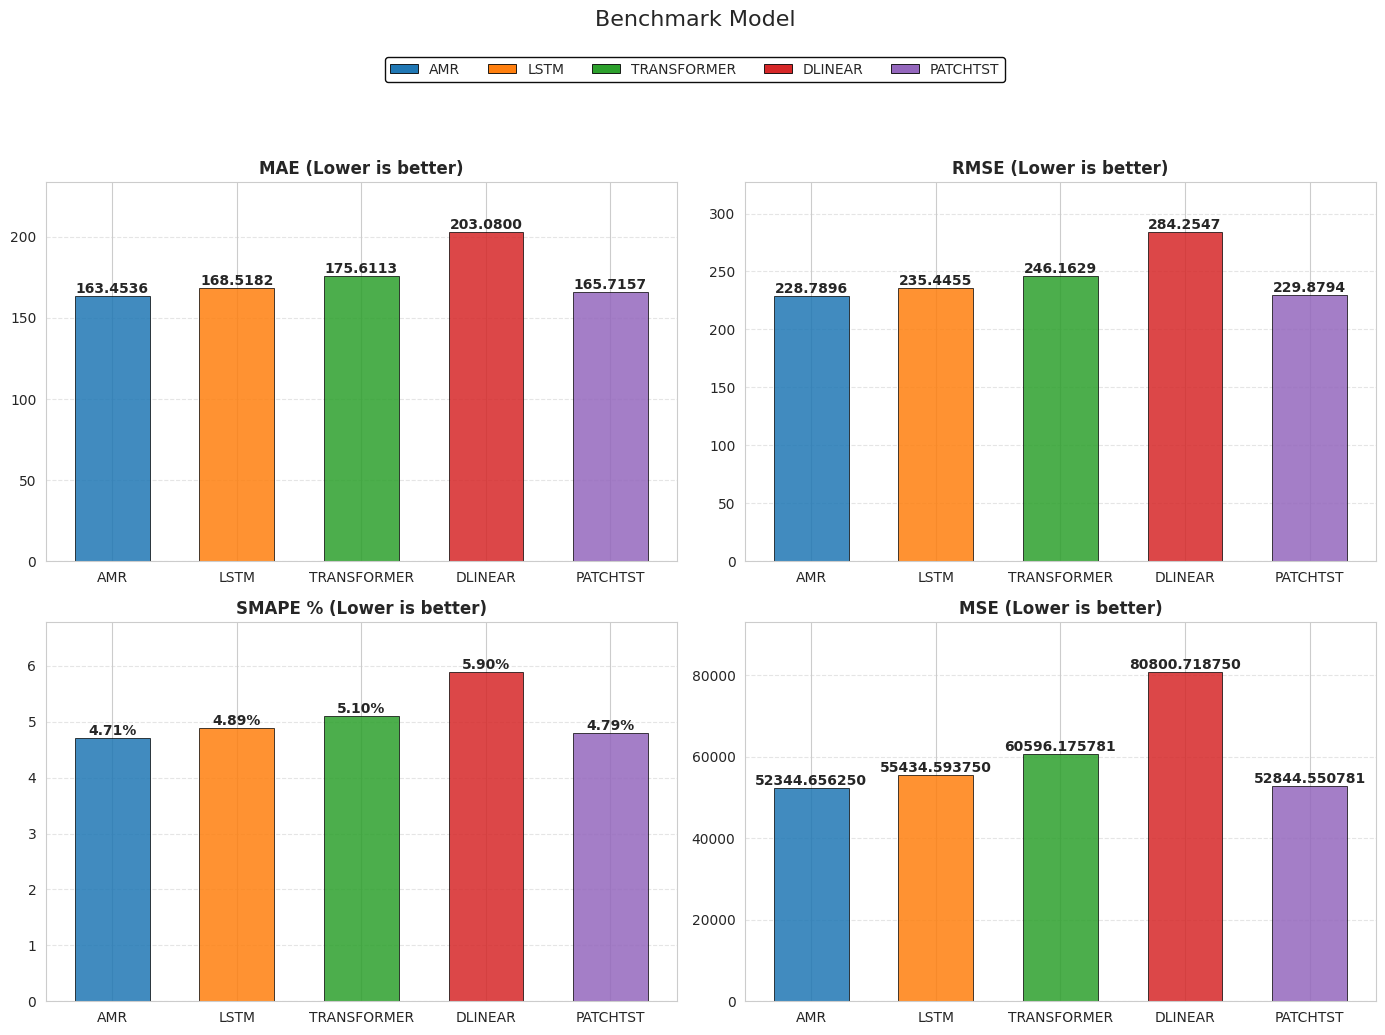

In [ ]:
models = list(summary.keys())
models_display = [m.upper() for m in models]

metrics_to_plot = ["mae", "rmse", "smape", "mse"]
titles = [
    "MAE (Lower is better)",
    "RMSE (Lower is better)",
    "SMAPE % (Lower is better)",
    "MSE (Lower is better)"
]

# --- COLORS: one color per model ---
cmap = plt.get_cmap("tab10")  
colors = [cmap(i % cmap.N) for i in range(len(models))]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    values = []

    # Collect values
    for m in models:
        if metric == "smape":
            val = summary[m].get("extra", {}).get("smape", 0)
        else:
            val = summary[m].get("metrics", {}).get(metric, 0)
        values.append(val)

    # Bar chart
    bars = ax.bar(
        models_display, values,
        color=colors, edgecolor="black", linewidth=0.6,
        alpha=0.85, width=0.6
    )

    # Y-axis limit
    if len(values) > 0:
        vmax = max(values)
        ax.set_ylim(0, vmax * 1.15 if vmax > 0 else 1)

    # Styling
    ax.set_title(titles[i], fontsize=12, fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    # Value labels on top of bars
    for bar in bars:
        height = bar.get_height()

        if metric == "smape":
            label = f"{height:.2f}%"
        elif metric == "mse":
            label = f"{height:.6f}"
        else:
            label = f"{height:.4f}"

        ax.text(
            bar.get_x() + bar.get_width() / 2.0, height,
            label,
            ha="center", va="bottom",
            fontsize=10, fontweight="bold"
        )

# --- LEGEND: boxed legend ---
handles = [plt.Rectangle((0, 0), 1, 1, color=colors[i], ec="black", lw=0.6)
           for i in range(len(models))]
fig.legend(
    handles, models_display,
    loc="upper center", ncol=len(models_display),
    bbox_to_anchor=(0.5, 0.99),
    frameon=True, fancybox=True, framealpha=0.95,
    edgecolor="black"
)

plt.suptitle("Benchmark Model", fontsize=16, y=1.03)
plt.tight_layout(rect=[0, 0, 1, 0.93])  # leave space for boxed legend + title
plt.show()


# Phân tích hiệu năng và trực quan kết quả

In [ ]:
# 1) Danh sách model cần phân tích
MODEL_NAMES = ['amr', 'lstm', 'transformer', 'dlinear', 'patchtst']

efficiency_data = {
    'model': [],
    'flops': [],
    'params': [],
    'inference_time_ms': []
}

def measure_inference_time_ms(model, x, iters=200, warmup=30):
    """
    Return: ms / batch
    """
    model.eval()
    with torch.inference_mode():
        # warmup
        for _ in range(warmup):
            _ = model(x)
        if x.is_cuda:
            torch.cuda.synchronize()

        t0 = time.time()
        for _ in range(iters):
            _ = model(x)
        if x.is_cuda:
            torch.cuda.synchronize()
        t1 = time.time()

    return (t1 - t0) * 1000.0 / iters

print("\n=== BẮT ĐẦU PHÂN TÍCH HIỆU SUẤT TÍNH TOÁN ===")

# batch size để đo time: dùng batch size của test_loader cho “ms/batch” 
try:
    B = next(iter(test_loader))[0].shape[0]
except Exception:
    B = 32  # fallback

for mname in MODEL_NAMES:
    m_key = mname.lower()
    print(f"\n--- Analyzing: {m_key.upper()} ---")

    if m_key not in MODEL_CONFIGS:
        print(f"[Warning] Không tìm thấy config cho {m_key}, bỏ qua.")
        continue

    cfg = MODEL_CONFIGS[m_key]

    # 1) Create model
    try:
        model_tmp = create_model(
            name=m_key,
            input_len=INPUT_LEN,
            output_len=OUTPUT_LEN,
            config=cfg
        ).to(device)
        model_tmp.eval()
    except Exception as e:
        print(f"[Error] create_model failed for {m_key}: {e}")
        continue

    # 2) Dummy input (same shape for all models)
    dummy_input = torch.randn(B, INPUT_LEN, 1, device=device)

    # 3) FLOPs & Params (THOP)
    try:
        flops, params = profile(model_tmp, inputs=(dummy_input,), verbose=False)
    except Exception as e:
        print(f"[Warning] THOP không tính được FLOPs/Params cho {m_key}: {e}")
        flops, params = np.nan, np.nan

    # 4) Inference time đo trực tiếp (ms/batch)
    try:
        inf_ms = measure_inference_time_ms(model_tmp, dummy_input, iters=200, warmup=30)
    except Exception as e:
        print(f"[Warning] Không đo được inference time cho {m_key}: {e}")
        inf_ms = np.nan

    efficiency_data['model'].append(m_key.upper())
    efficiency_data['flops'].append(flops)
    efficiency_data['params'].append(params)
    efficiency_data['inference_time_ms'].append(inf_ms)

    flops_str, params_str = clever_format([flops, params], "%.3f") if np.isfinite(flops) else ("NaN", "NaN")
    print(f"[{m_key.upper()}] FLOPs: {flops_str}, Params: {params_str}, Time: {inf_ms:.2f} ms/batch")

    # cleanup
    del model_tmp
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

print("\n=== BẢNG TỔNG HỢP HIỆU SUẤT (EFFICIENCY TABLE) ===")
df_eff = pd.DataFrame(efficiency_data)
df_eff['GFLOPs'] = df_eff['flops'] / 1e9
df_eff['MParams'] = df_eff['params'] / 1e6
df_eff['Time(ms)'] = df_eff['inference_time_ms']

final_cols = ['model', 'GFLOPs', 'MParams', 'Time(ms)']
print(df_eff[final_cols])

# Lưu kết quả
df_eff.to_csv(os.path.join(out_dir, 'computational_efficiency.csv'), index=False)



=== BẮT ĐẦU PHÂN TÍCH HIỆU SUẤT TÍNH TOÁN ===

--- Analyzing: AMR ---
[AMR] FLOPs: 1.594G, Params: 745.025K, Time: 20.61 ms/batch

--- Analyzing: LSTM ---
[LSTM] FLOPs: 210.764M, Params: 158.863K, Time: 0.64 ms/batch

--- Analyzing: TRANSFORMER ---
[TRANSFORMER] FLOPs: 2.424G, Params: 885.839K, Time: 3.43 ms/batch

--- Analyzing: DLINEAR ---
[DLINEAR] FLOPs: 95.232K, Params: 2.910K, Time: 0.36 ms/batch

--- Analyzing: PATCHTST ---


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[PATCHTST] FLOPs: 35.842M, Params: 111.695K, Time: 1.23 ms/batch

=== BẢNG TỔNG HỢP HIỆU SUẤT (EFFICIENCY TABLE) ===
         model    GFLOPs   MParams   Time(ms)
0          AMR  1.593528  0.745025  20.605682
1         LSTM  0.210764  0.158863   0.637662
2  TRANSFORMER  2.423783  0.885839   3.433738
3      DLINEAR  0.000095  0.002910   0.364462
4     PATCHTST  0.035842  0.111695   1.231889


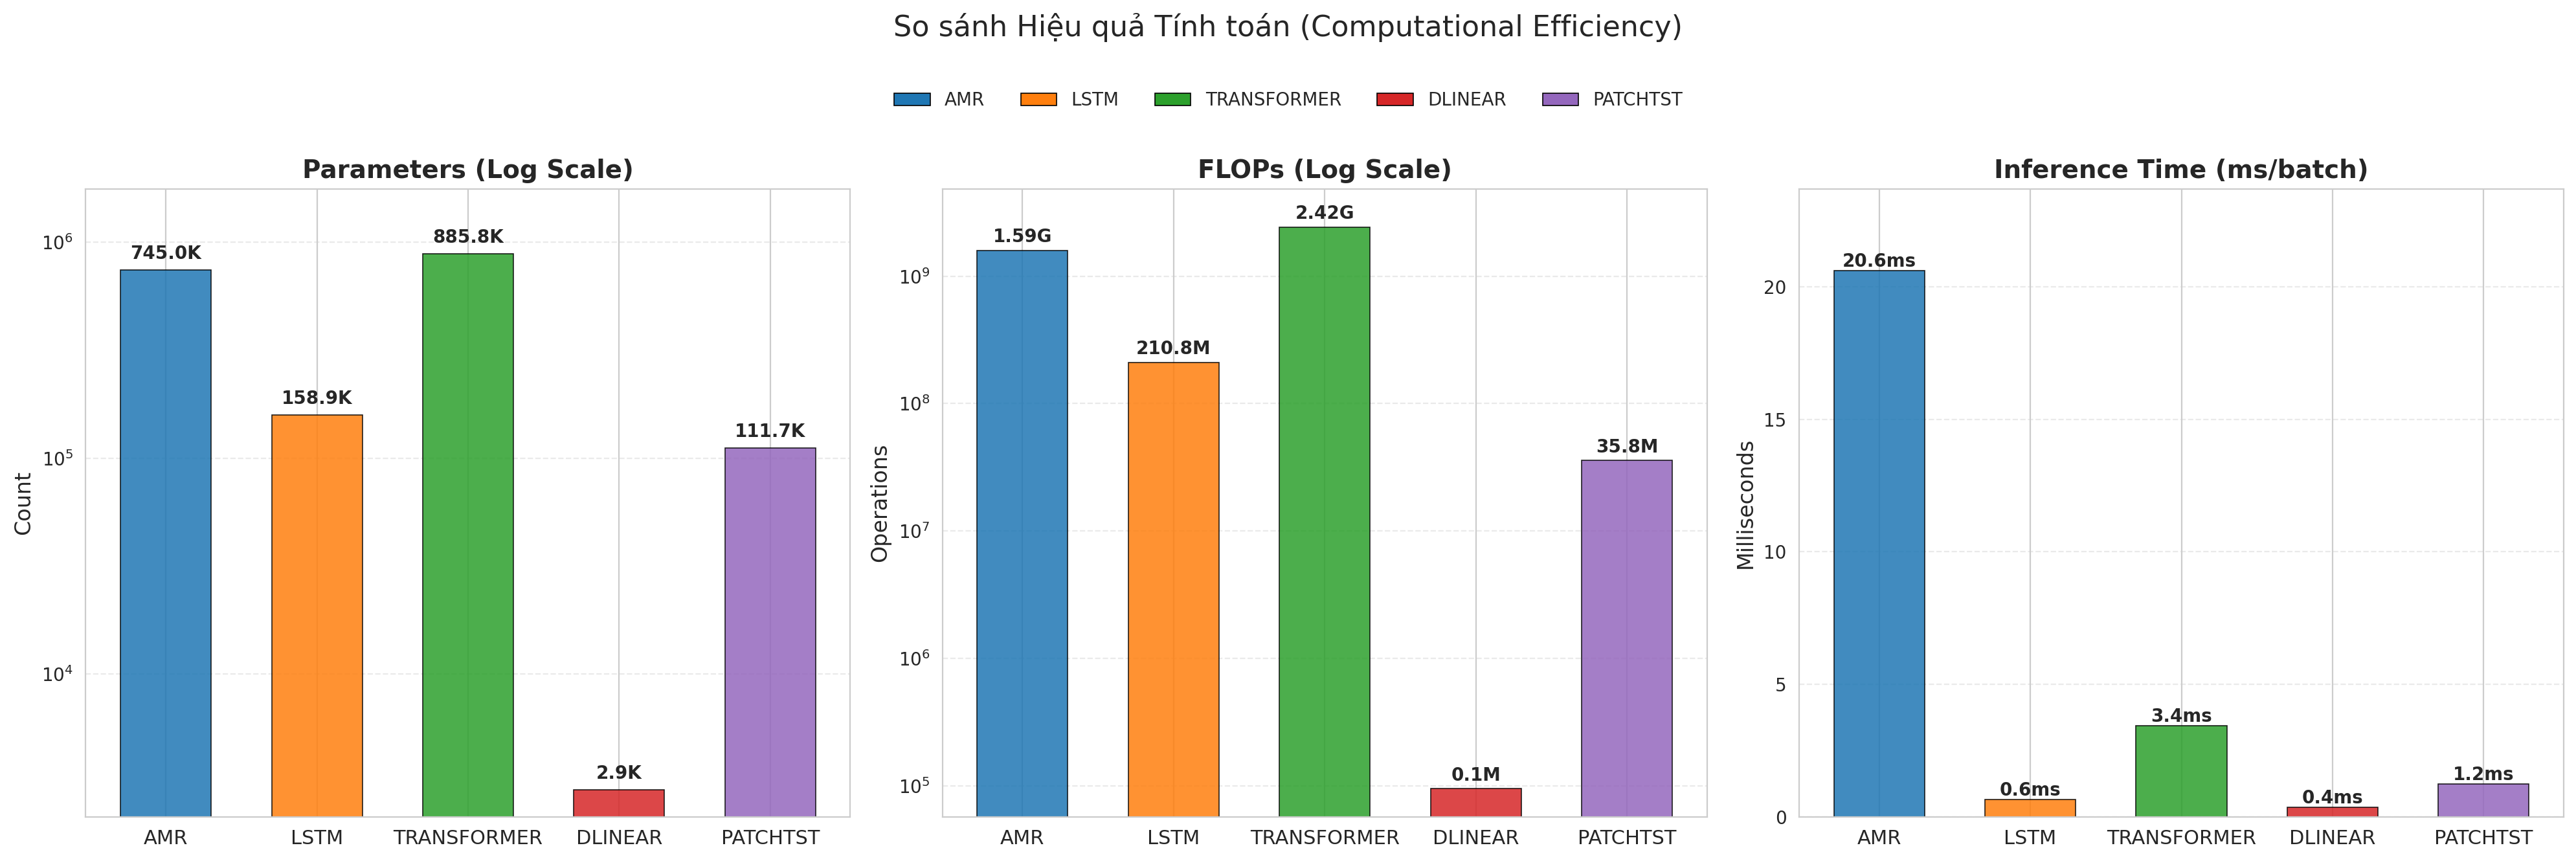

In [ ]:
models = efficiency_data['model']
params_vals = np.array(efficiency_data['params'], dtype=float)
flops_vals  = np.array(efficiency_data['flops'], dtype=float)
time_vals   = np.array(efficiency_data.get('inference_time_ms', [np.nan]*len(models)), dtype=float)

x = np.arange(len(models))
width = 0.6

# an toàn cho log-scale (không cho 0/NaN)
params_plot = np.where(np.isfinite(params_vals) & (params_vals > 0), params_vals, np.nan)
flops_plot  = np.where(np.isfinite(flops_vals)  & (flops_vals  > 0), flops_vals,  np.nan)

# --- MÀU ---
cmap = plt.get_cmap("tab10")  
colors = [cmap(i % cmap.N) for i in range(len(models))]

fig, ax = plt.subplots(1, 3, figsize=(20, 6), dpi=200)

# --- PARAMS ---
rects1 = ax[0].bar(x, np.nan_to_num(params_plot, nan=1.0), width,
                   color=colors, edgecolor="black", linewidth=0.6, alpha=0.85)
ax[0].set_yscale('log')
ax[0].set_title('Parameters (Log Scale)', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Count', fontsize=12)
ax[0].set_xticks(x)
ax[0].set_xticklabels(models, fontsize=11, rotation=0)
ax[0].grid(axis='y', linestyle='--', alpha=0.4)
ax[0].set_ylim(top=np.nanmax(params_plot) * 2.0 if np.isfinite(np.nanmax(params_plot)) else 10)

for rect, val in zip(rects1, params_vals):
    if not np.isfinite(val) or val <= 0:
        continue
    height = rect.get_height()
    label = f'{val/1e6:.2f}M' if val >= 1e6 else f'{val/1e3:.1f}K'
    ax[0].text(rect.get_x() + rect.get_width()/2., height * 1.08,
               label, ha='center', va='bottom', fontweight='bold', fontsize=10)

# --- FLOPs ---
rects2 = ax[1].bar(x, np.nan_to_num(flops_plot, nan=1.0), width,
                   color=colors, edgecolor="black", linewidth=0.6, alpha=0.85)
ax[1].set_yscale('log')
ax[1].set_title('FLOPs (Log Scale)', fontsize=14, fontweight='bold')
ax[1].set_ylabel('Operations', fontsize=12)
ax[1].set_xticks(x)
ax[1].set_xticklabels(models, fontsize=11, rotation=0)
ax[1].grid(axis='y', linestyle='--', alpha=0.4)
ax[1].set_ylim(top=np.nanmax(flops_plot) * 2.0 if np.isfinite(np.nanmax(flops_plot)) else 10)

for rect, val in zip(rects2, flops_vals):
    if not np.isfinite(val) or val <= 0:
        continue
    height = rect.get_height()
    label = f'{val/1e9:.2f}G' if val >= 1e9 else f'{val/1e6:.1f}M'
    ax[1].text(rect.get_x() + rect.get_width()/2., height * 1.08,
               label, ha='center', va='bottom', fontweight='bold', fontsize=10)

# --- INFERENCE TIME ---
rects3 = ax[2].bar(x, time_vals, width,
                   color=colors, edgecolor="black", linewidth=0.6, alpha=0.85)
ax[2].set_title('Inference Time (ms/batch)', fontsize=14, fontweight='bold')
ax[2].set_ylabel('Milliseconds', fontsize=12)
ax[2].set_xticks(x)
ax[2].set_xticklabels(models, fontsize=11, rotation=0)
ax[2].grid(axis='y', linestyle='--', alpha=0.4)

if np.isfinite(np.nanmax(time_vals)):
    ax[2].set_ylim(0, np.nanmax(time_vals) * 1.15)

for rect, val in zip(rects3, time_vals):
    if not np.isfinite(val):
        continue
    height = rect.get_height()
    ax[2].text(rect.get_x() + rect.get_width()/2., height,
               f'{val:.1f}ms', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Legend chung
handles = [plt.Rectangle((0, 0), 1, 1, color=colors[i], ec="black", lw=0.6) for i in range(len(models))]
fig.legend(handles, models, loc="upper center", ncol=len(models), frameon=False, bbox_to_anchor=(0.5, 1.02))

plt.suptitle('So sánh Hiệu quả Tính toán (Computational Efficiency)', fontsize=16, y=1.10)
plt.tight_layout()
plt.show()



=== DỰ BÁO vs THỰC TẾ: AMR ===
[Info] Đã load trọng số từ best_model_amr.pt


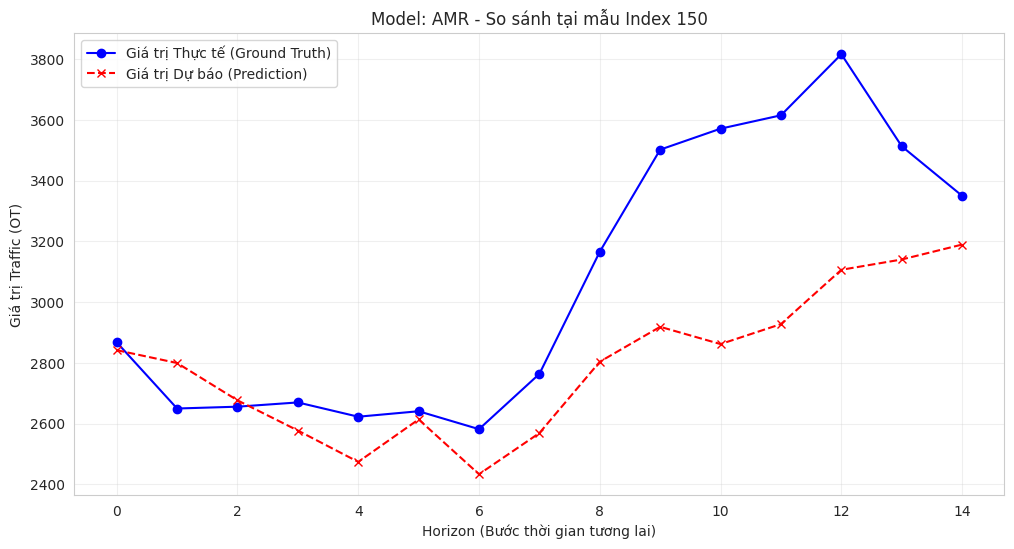


=== DỰ BÁO vs THỰC TẾ: LSTM ===
[Info] Đã load trọng số từ best_model_lstm.pt


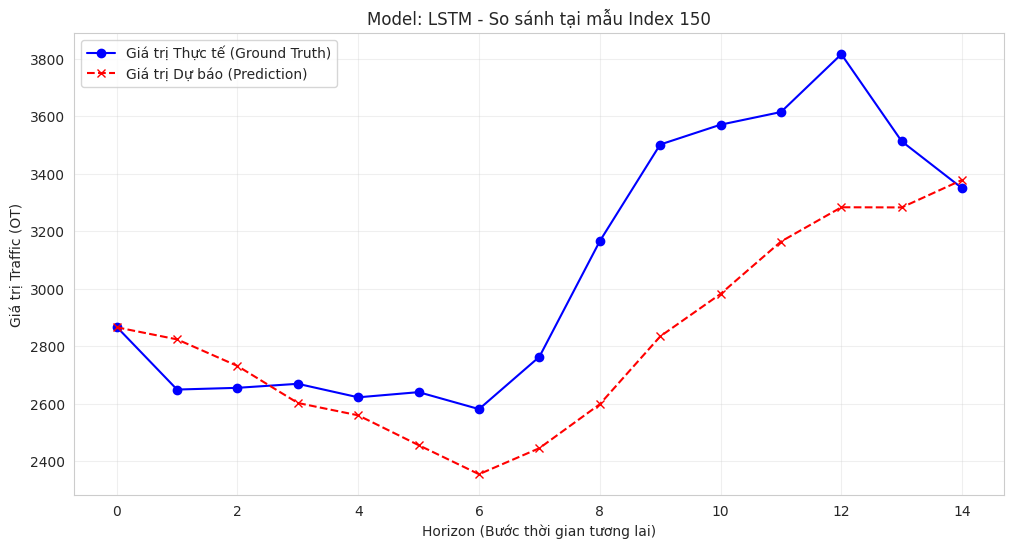


=== DỰ BÁO vs THỰC TẾ: TRANSFORMER ===
[Info] Đã load trọng số từ best_model_transformer.pt


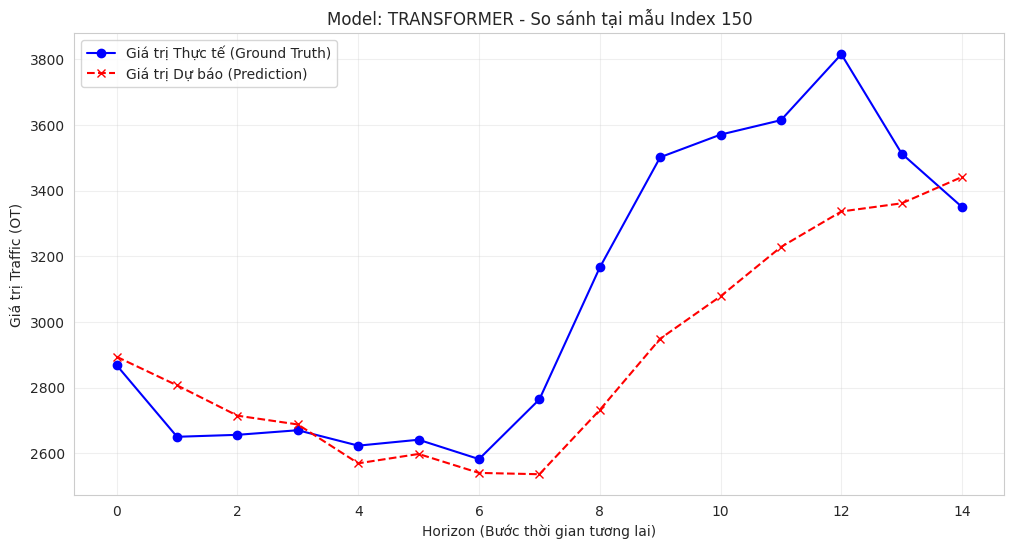


=== DỰ BÁO vs THỰC TẾ: DLINEAR ===
[Info] Đã load trọng số từ best_model_dlinear.pt


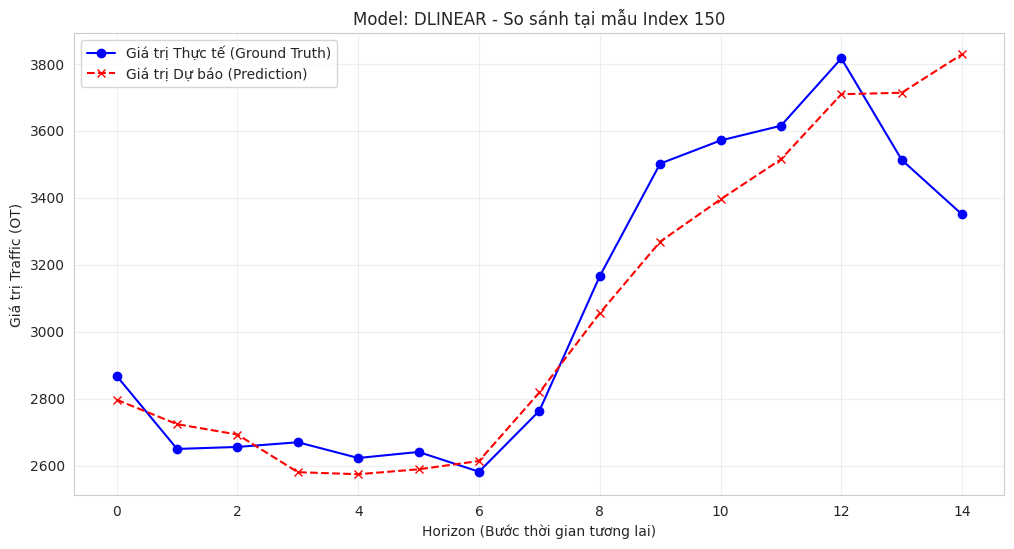


=== DỰ BÁO vs THỰC TẾ: PATCHTST ===
[Info] Đã load trọng số từ best_model_patchtst.pt


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


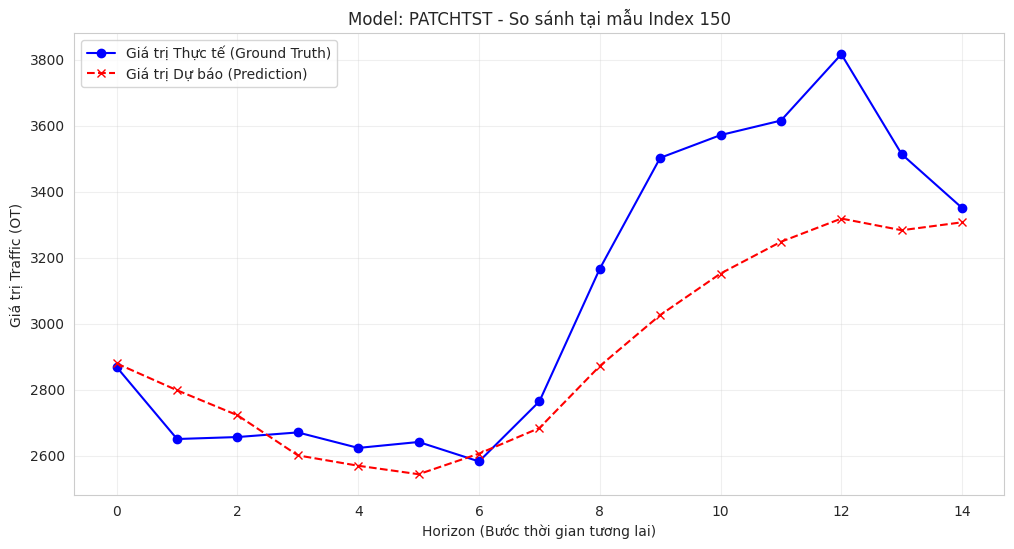

In [29]:
MODEL_NAMES = ['amr', 'lstm', 'transformer', 'dlinear', 'patchtst']

for mname in MODEL_NAMES:
    print(f"\n=== DỰ BÁO vs THỰC TẾ: {mname.upper()} ===")

    if mname not in MODEL_CONFIGS:
        print(f"[Warning] Không tìm thấy config cho {mname}, bỏ qua.")
        continue

    cfg = MODEL_CONFIGS[mname]

    # --- 1) Tạo model ---
    try:
        model = create_model(
            name=mname,
            input_len=INPUT_LEN,
            output_len=OUTPUT_LEN,
            config=cfg
        )
    except Exception as e:
        print(f"[Error] create_model failed for {mname}: {e}")
        continue

    # --- 2) Load Weights
    model_path = f'best_model_{mname}.pt'
    if os.path.exists(model_path):
        try:
            model.load_state_dict(torch.load(model_path, map_location=device))
            print(f"[Info] Đã load trọng số từ {model_path}")
        except Exception as e:
            print(f"[Warning] Không thể load {model_path}: {e}")
            print("-> Đang sử dụng trọng số ngẫu nhiên (Biểu đồ sẽ không chính xác)")
    else:
        print(f"[Warning] File {model_path} không tồn tại. Đang dùng trọng số ngẫu nhiên!")

    # --- 3) Move model to device and eval ---
    model = model.to(device)
    model.eval()

    # --- 4) Forecast on test_loader ---
    all_preds_orig, all_labels_orig = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs).cpu().numpy()

            # Normalize shapes: squeeze final dim if present
            if outputs.ndim == 3 and outputs.shape[-1] == 1:
                outputs = outputs.squeeze(-1)

            if labels.ndim == 3 and labels.shape[-1] == 1:
                labels_np = labels.numpy().squeeze(-1)
            else:
                labels_np = labels.numpy()

            # Inverse transform
            try:
                inv_out = scaler.inverse_transform(outputs)
            except Exception:
                # Fallback nếu lỗi shape (thường gặp với batch size lẻ)
                n_batch = outputs.shape[0]
                inv_out = np.vstack([scaler.inverse_transform(outputs[i].reshape(-1,1)).reshape(1,-1) for i in range(n_batch)])

            try:
                inv_labels = scaler.inverse_transform(labels_np)
            except Exception:
                n_batch = labels_np.shape[0]
                inv_labels = np.vstack([scaler.inverse_transform(labels_np[i].reshape(-1,1)).reshape(1,-1) for i in range(n_batch)])

            all_preds_orig.append(inv_out)
            all_labels_orig.append(inv_labels)

    if len(all_preds_orig) == 0:
        print(f"[Warning] Không có dự báo nào cho {mname}. Bỏ qua vẽ.")
        continue

    all_preds_orig = np.concatenate(all_preds_orig, axis=0)
    all_labels_orig = np.concatenate(all_labels_orig, axis=0)

    # --- 5) Plot a sample ---
    sample_idx = min(150, all_preds_orig.shape[0] - 1)

    plt.figure(figsize=(12, 6))
    plt.plot(all_labels_orig[sample_idx], label='Giá trị Thực tế (Ground Truth)', marker='o', color='blue')
    plt.plot(all_preds_orig[sample_idx], label='Giá trị Dự báo (Prediction)', marker='x', linestyle='--', color='red')

    plt.title(f'Model: {mname.upper()} - So sánh tại mẫu Index {sample_idx}')
    plt.xlabel('Horizon (Bước thời gian tương lai)')
    plt.ylabel('Giá trị Traffic (OT)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Free GPU memory
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

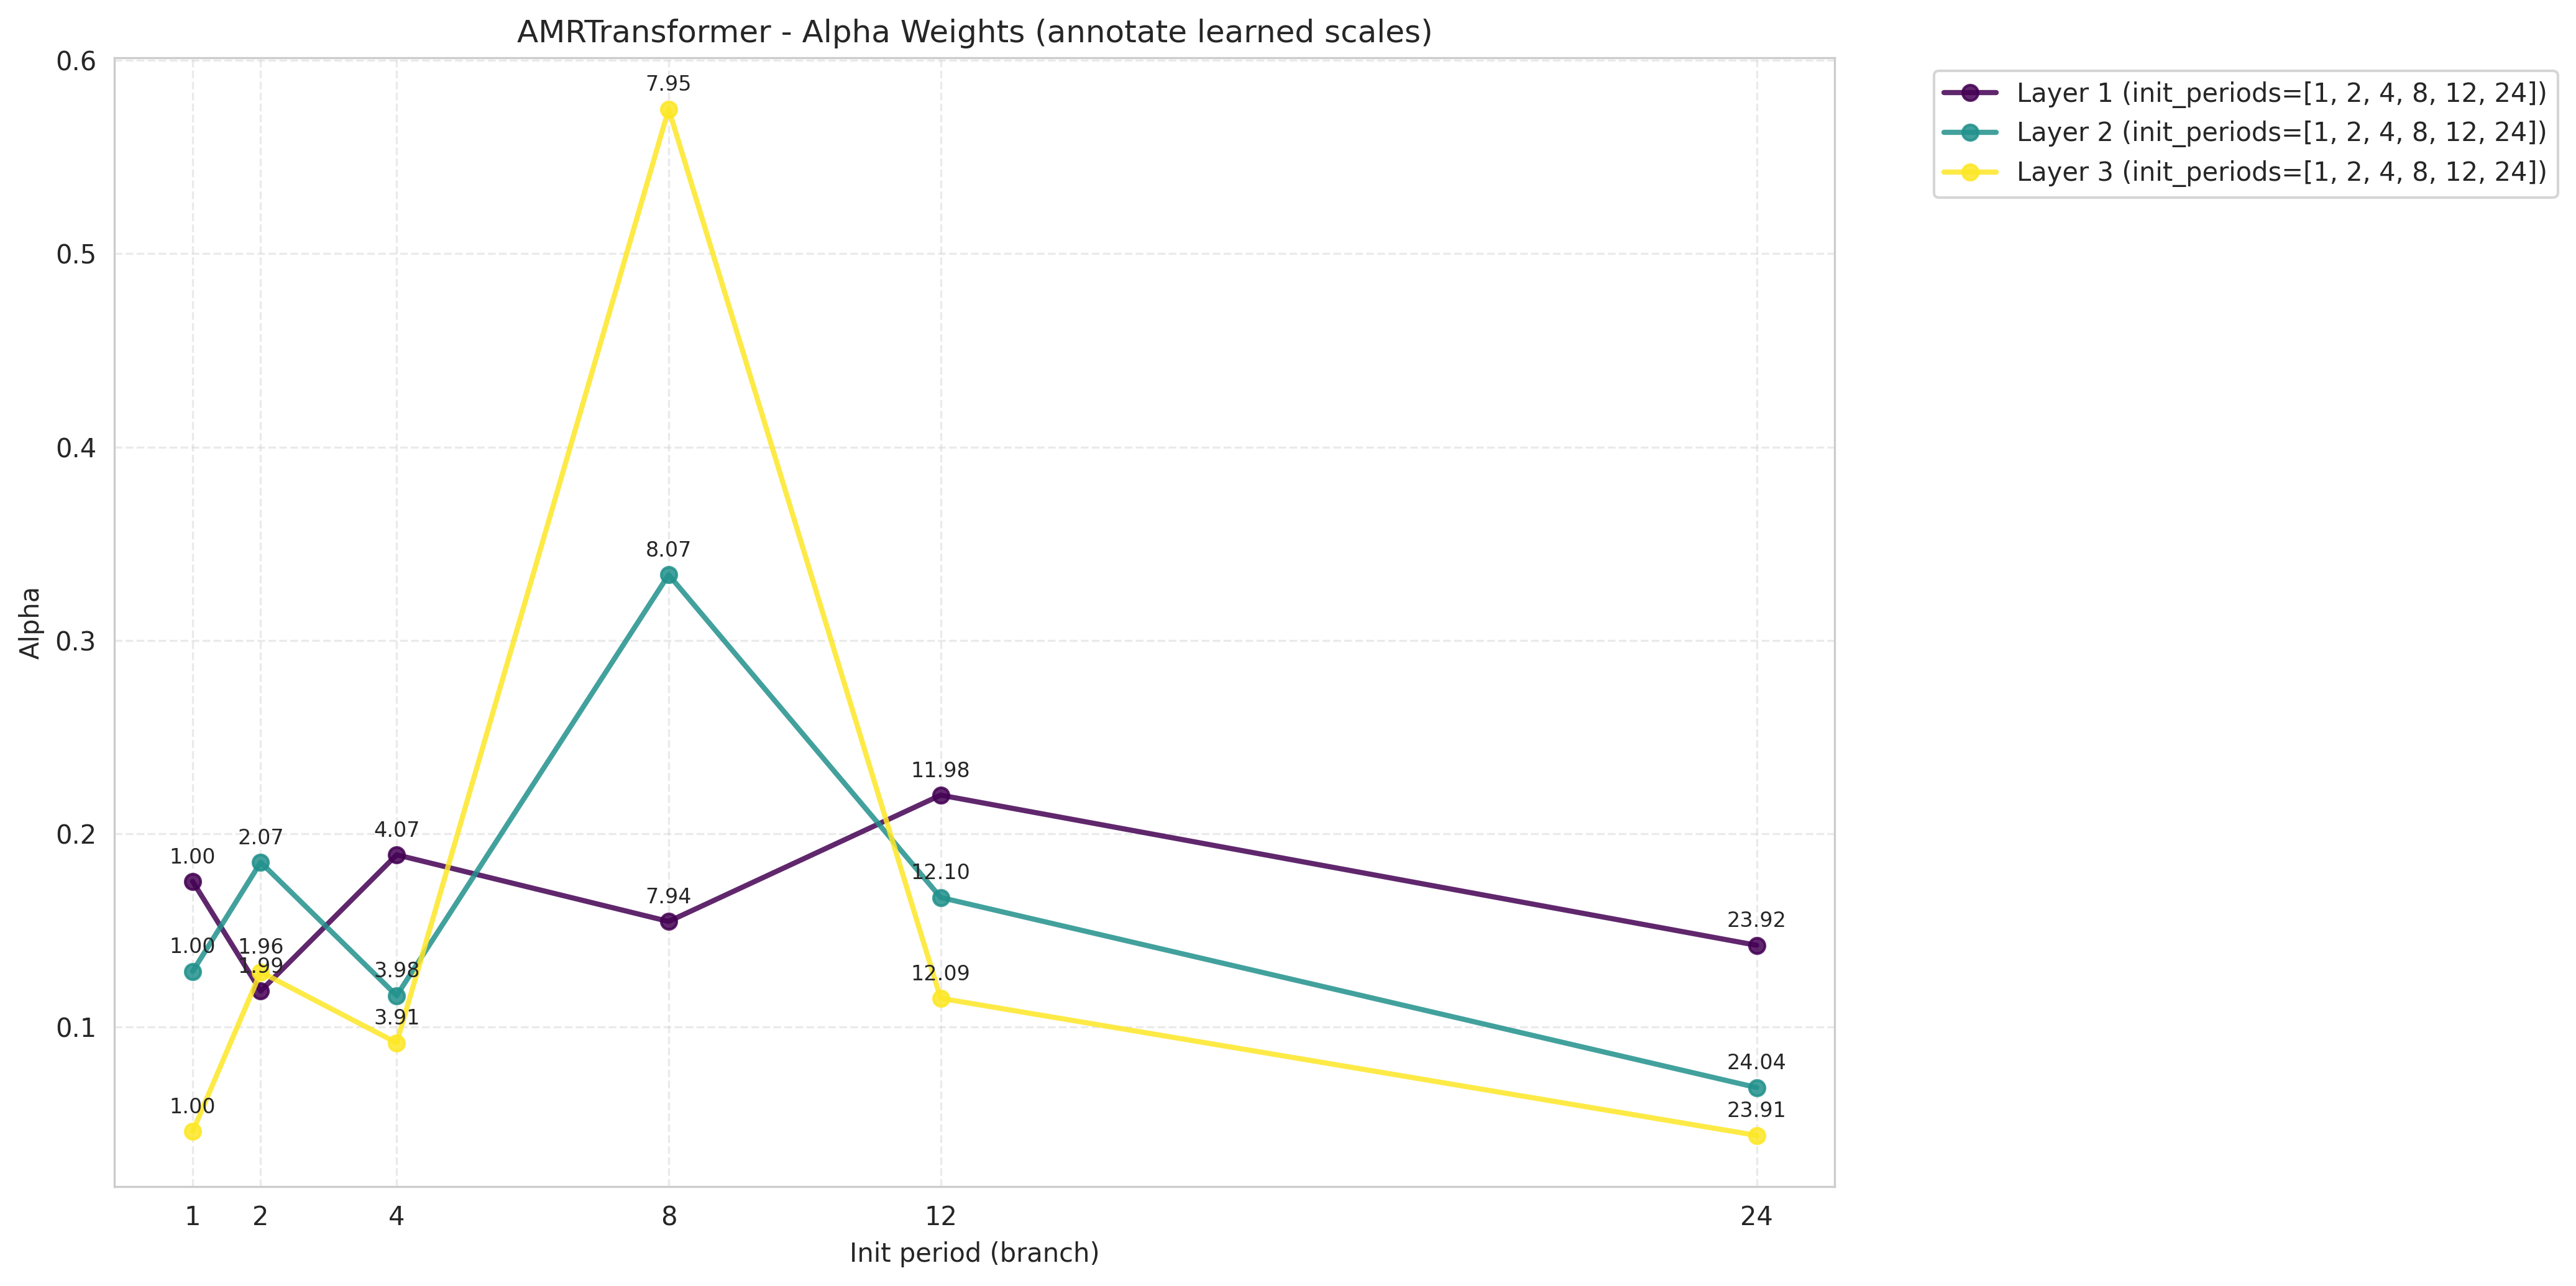

In [ ]:
# --- PLOT ALPHA + ANNOTATE LEARNED SCALES (self-contained, safe) ---

# 0) Load AMR model explicitly 
amr_cfg = MODEL_CONFIGS.get("amr", {"d_model": 64, "nhead": 4, "num_layers": 3, "dropout": 0.1})
model = create_model("amr", INPUT_LEN, OUTPUT_LEN, amr_cfg).to(device)

ckpt = "best_model_amr.pt"
state = torch.load(ckpt, map_location=device)
model.load_state_dict(state)
model.eval()

# 1) Forward 1 batch để populate alpha_tracker/scale_tracker
inputs, _ = next(iter(test_loader))
with torch.no_grad():
    _ = model(inputs.to(device))

# 2) alpha_storage
if hasattr(model, "alpha_tracker") and len(model.alpha_tracker) > 0:
    alpha_storage = model.alpha_tracker
elif hasattr(model, "alpha_weights_per_layer") and len(model.alpha_weights_per_layer) > 0:
    alpha_storage = model.alpha_weights_per_layer
else:
    raise ValueError("Không thấy alpha_tracker/alpha_weights_per_layer sau forward().")

# 3) xticks tự động từ init_periods
all_periods = set()
for layer in getattr(model, "layers", []):
    if hasattr(layer, "init_periods"):
        all_periods.update(list(layer.init_periods))

# 4) Plot
fig, ax = plt.subplots(figsize=(14, 7), dpi=300)
colors = plt.cm.viridis(np.linspace(0, 1, max(1, len(model.layers))))

for i, layer in enumerate(model.layers):
    if i >= len(alpha_storage):
        continue

    periods = list(getattr(layer, "init_periods", []))
    a = alpha_storage[i]
    alphas = a.mean(dim=0).detach().cpu().numpy()

    # safety
    if len(periods) != len(alphas):
        periods = list(range(len(alphas)))

    ax.plot(periods, alphas, marker="o", linewidth=2, color=colors[i],
            label=f"Layer {i+1} (init_periods={periods})", alpha=0.85)

    # annotate learned scales
    if hasattr(model, "scale_tracker") and i < len(model.scale_tracker):
        scales = model.scale_tracker[i]
        if isinstance(scales, list) and len(scales) == len(alphas):
            for p, y, s in zip(periods, alphas, scales):
                s_val = float(s.detach().cpu().item()) if isinstance(s, torch.Tensor) else float(s)
                ax.annotate(f"{s_val:.2f}", (p, y),
                            textcoords="offset points", xytext=(0, 7),
                            ha="center", fontsize=8)

ax.set_title("AMRTransformer - Alpha Weights (annotate learned scales)")
ax.set_xlabel("Init period (branch)")
ax.set_ylabel("Alpha")

if len(all_periods) > 0:
    ax.set_xticks(sorted(all_periods))  

ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
fig.tight_layout()
plt.show()
